# *Mission 12 - DEIMOS II*

In [27]:
import difflib
from datetime import date, timedelta
from rocketpy import Environment, SolidMotor, Rocket, Flight, Function

## Corretor Fuzzy

In [28]:
def corretor_fuzzy(input_usuario, lista_valida, nome_parametro = "Parâmetro", cutoff = 0.5, verbose = True):
    """
    Descrição: Atua como um filtro de segurança computacional para corrigir erros de digitação (typos) e inconsistências de 
    maiúsculas/minúsculas nas entradas do usuário. Garante que as classes do RocketPy recebam as strings exatamente no formato 
    estrito exigido pelo framework.

    Mecânica de Funcionamento (3 Camadas):
    1. Normalização: Converte o input e a lista válida para minúsculas e tenta um match exato (resolvendo erros de "Caps Lock").
    2. Motor Fuzzy: Caso falhe, usa o algoritmo de Levenshtein (difflib) para buscar a opção estatisticamente mais semelhante na lista.
    3. Fallback: Se a semelhança for menor que o limite de corte (cutoff), repassa a palavra original limpa para não bloquear 
    bibliotecas futuras.

    Parâmetros:
    - input_usuario (str): A string bruta repassada pela função original.
    - lista_valida (list): Lista de strings oficiais que o sistema espera receber.
    - nome_parametro (str): Nome da variável analisada. Útil para impressão de logs.
    - cutoff (float): Nível de rigor da correção (de 0.0 a 1.0). Um cutoff de 0.5 exige no mínimo 50% de similaridade (Padrão: 0.5).
    - verbose (bool): Se True, notifica no terminal se uma correção autônoma foi aplicada (Padrão: True).

    Retorno:
    - (str): A string validada com a capitalização (maiúsculas/minúsculas) oficial da lista. Em caso de falha profunda, retorna 
    o original.

    Guia de Manutenção (Como adicionar novos parâmetros/opções):
    Para que o corretor passe a reconhecer um novo motor chamado "MOON", basta ir na função `set_motor` e adicionar a palavra na 
    lista local:
    De:  opcoes_motor = ["BATES", "ESTRELA"]
    Para: opcoes_motor = ["BATES", "ESTRELA", "MOON"]
    """
    
    input_limpo = str(input_usuario).strip().lower()
    mapa_lower = {opt.lower(): opt for opt in lista_valida}

    # 1. Match exato (ignora apenas maiúsculas/minúsculas)
    if input_limpo in mapa_lower:
        return mapa_lower[input_limpo]

    # 2. Busca aproximada (Fuzzy)
    match = difflib.get_close_matches(input_limpo, mapa_lower.keys(), n=1, cutoff=cutoff)
    if match:
        correcao = mapa_lower[match[0]]
        if verbose:
            print(f"[Corretor] '{nome_parametro}' ajustado de '{input_usuario}' para '{correcao}'.")
        return correcao

    # 3. Fallback: Devolve o original se o erro for muito grande
    return str(input_usuario).strip()

## Environment

In [29]:
# Determinando o dia e horário do lançamento
LAUNCH_DAYS_FROM_NOW = 5                        # Daqui a X dias
LAUNCH_HOUR = 8                                 # Hora local (fuso de São Paulo), formato 24h 

In [30]:
from datetime import date, timedelta
from rocketpy import Environment

def set_env(days_to_launch = LAUNCH_DAYS_FROM_NOW, hour = LAUNCH_HOUR, atm_type = "Windy", atm_file = "ECMWF", max_altitude = 1800, datum = "SIRGAS2000", verbose = False): 
    """
    Descrição: Script para configuração dinâmica do ambiente de lançamento (clima, topografia e coordenadas) no Sugarcane Launch Range.
            
    Parâmetros:
    - days_to_launch (int): Dias para o lançamento.
    - hour (float): Hora do lançamento.
    - atm_type (str): Fonte dos dados. Ex: "Windy", "forecast" ou "standard_atmosphere".
    - atm_file (str): O modelo meteorológico. Ex: "ECMWF", "GFS", "ICON".
    - max_altitude (float): Altitude máxima [m] para processamento de dados climáticos.
    - datum (str): Modelo elipsoidal de referência. Ex: "SIRGAS2000", "WGS84", "SAD69". 
        O modelo "SIRGAS2000" é o geodésico oficial adotado no Brasil (ideal para a LASC).
    - verbose (bool): Se True, exibe logs e gráficos detalhados.
    """

    # ==========================================
    # DICIONÁRIO DE VALIDAÇÃO DE PARÂMETROS
    # ==========================================
    opcoes_atm_type = ["Windy", "forecast", "standard_atmosphere", "Reanalysis", "Ensemble"]
    opcoes_atm_file = ["ECMWF", "GFS", "ICON", "NAM"] 
    opcoes_datum = ["SAD69", "WGS84", "NAD83", "SIRGAS2000"]

    # Aplicando o corretor global (Fuzzy Matching)
    atm_type_limpo = corretor_fuzzy(atm_type, opcoes_atm_type, "atm_type", verbose = verbose)
    atm_file_limpo = corretor_fuzzy(atm_file, opcoes_atm_file, "atm_file", verbose = verbose)
    datum_type_limpo = corretor_fuzzy(datum, opcoes_datum, "datum", verbose = verbose)
    
    # ==========================================
    # LOG DE INICIALIZAÇÃO
    # ==========================================
    if days_to_launch == 0:
        dia_texto = "hoje"
    elif days_to_launch == 1:
        dia_texto = "amanhã"
    else:
        dia_texto = f"daqui a {days_to_launch} dias"
        
    if verbose:
        print(f"Configurando ambiente para {dia_texto} à(s) {hour} h")
            
    # ==========================================
    # 1. CONFIGURAÇÃO DE COORDENADAS E DATUM
    # ==========================================
    env = Environment(
        latitude = -21.9430589, 
        longitude = -48.9524268, 
        datum = datum_type_limpo
    )
    
    # ==========================================
    # 2. CONFIGURAÇÃO DE DATA E HORA
    # ==========================================
    target_date = date.today() + timedelta(days = days_to_launch)
    date_info = (target_date.year, target_date.month, target_date.day, hour)
    env.set_date(date_info, timezone = "America/Sao_Paulo")
    
    # ==========================================
    # 3. PREVISÃO ATMOSFÉRICA DINÂMICA
    # ==========================================
    if verbose:
        print(f"Baixando dados atmosféricos via {atm_type_limpo} (Modelo: {atm_file_limpo})")
        
    env.set_atmospheric_model(type = atm_type_limpo, file = atm_file_limpo)

    # ==========================================
    # 4. CONFIGURAÇÃO TOPOGRÁFICA E OTIMIZAÇÃO
    # ==========================================
    # Altitude máxima esperada, utilizada para otimização dos cálculos atmosféricos
    env.max_expected_altitude = max_altitude
    
    if verbose:
        print(f"Carregando perfil topográfico e limitando altitude para {max_altitude} m")
        
    env.set_topographic_profile(
        type = "NASADEM_HGT",
        file = "NASADEM_NC_s22w049.nc", 
        dictionary = "netCDF4",
    )
    
    elevation = env.get_elevation_from_topographic_profile(env.latitude, env.longitude)
    env.set_elevation(elevation)
    
    if verbose:
        print(f"Elevação da base definida para: {elevation:.2f} metros ASL.")
    
    # ==========================================
    # 5. EXIBIÇÃO DE DADOS E GRÁFICOS
    # ==========================================
    if verbose:
        print("\n--- Resumo do Ambiente ---")
        env.info()
        print("\n--- Gerando Gráficos Atmosféricos ---\n")
        print("Vento_Leste-Oeste:", env.wind_velocity_x(0))                 # > 0 = Leste
        print("Vento_Norte-Sul:", env.wind_velocity_y(0))                   # > 0 = Norte
        env.plots.atmospheric_model()
        print("\n--- Ambiente de Lançamento configurado com sucesso ---")
    
    return env

## Motor

In [31]:
def set_motor(motor_name = "BATES", interpolation_method = "linear", grain_separation = 0.003, verbose = False):
    """
    Descrição: Script para configuração e instanciação do sistema de propulsão sólida. Executa a montagem do motor baseada na 
    geometria de grão escolhida.

    Parâmetros:
    - motor_name (str): A configuração do grão que você quer rodar (Padrão: "BATES").
    - interpolation_method (str): Método de interpolação utilizado para obter a curva de empuxo com os pontos fornecidos no .eng.
        Ex: "linear", "spline" ou "akima".
    - grain_separation (float): Distância [m] entre os grãos de propelente.
    - verbose (bool): Se True, exibe os logs e gráficos detalhados.
    """

    # ==========================================
    # NORMALIZAÇÃO E MAPEAMENTO DE INPUTS
    # ==========================================
    opcoes_motor = ["BATES", "ESTRELA"]
    opcoes_interp = ["linear", "spline", "akima"]

    motor_limpo = corretor_fuzzy(motor_name, opcoes_motor, "motor_name", verbose = verbose)
    interp_limpa = corretor_fuzzy(interpolation_method, opcoes_interp, "interpolation_method", verbose = verbose).lower()
    
    if verbose:
        print(f"Carregando Motor: {motor_limpo} (Interpolação: {interp_limpa})\n")

    # ==========================================
    # 1. INSTANCIAÇÃO DO MOTOR
    # ==========================================
    if motor_limpo == 'BATES':
        motor = SolidMotor(
            thrust_source = r"FAISCABATES.eng",
            reshape_thrust_curve = False,
            dry_mass = 0.510,                               # [Fonte: Eng [Kg]]
            dry_inertia = (0.001, 0.001, 0.00004518),       # [Fonte: Fusion [Kg*m²]]
            burn_time = 3.048,                              # [Fonte: Teste estático [s]]
            center_of_dry_mass_position = 0.190255,         # [Fonte: CAD [m]]

            grain_number = 3,
            grain_density = 1500,
            grain_outer_radius = 0.02100,                   # [Fonte: Geometria do Grão BATES]
            grain_initial_inner_radius = 0.00635,           # [Fonte: Geometria do Grão BATES]
            grain_initial_height = 0.11000,                 # [Fonte: Geometria do Grão BATES]
            grain_separation = grain_separation,            # [Fonte: CAD [m]]
            grains_center_of_mass_position = 0.194148,      # [Fonte: CAD [m]]
            
            nozzle_position = 0,                            # Origem do sistema de coordenadas do motor
            nozzle_radius = 0.01185,                        # [Fonte: CAD [m]]
            throat_radius = 0.00475,                        # [Fonte: CAD [m]]

            coordinate_system_orientation = "nozzle_to_combustion_chamber",
            interpolation_method = interp_limpa
        )

    elif motor_limpo == 'ESTRELA':
        motor = SolidMotor(
            thrust_source = r"FAISCASTAR.eng",
            reshape_thrust_curve = False,
            dry_mass = 0.425007,                            # [Fonte: Eng [Kg]]
            dry_inertia = (0.004261, 0.004261, 0.000218),   # [Fonte: Fusion [Kg*m²]]
            burn_time = 1.48,                               # [Fonte: Eng [s]]
            center_of_dry_mass_position = 0.145,            # [Fonte: CAD [m]]

            grain_number = 2,
            grain_density = 1750,
            grain_outer_radius = 0.0213125,                 # [Fonte: Geometria do Grão STAR]
            grain_initial_inner_radius = 0.00704,           # [Fonte: Geometria do Grão STAR]
            grain_initial_height = 0.105,                   # [Fonte: Geometria do Grão STAR]
            grain_separation = grain_separation,            # [Fonte: CAD [m]]
            grains_center_of_mass_position = 0.1075,        # [Fonte: CAD [m]]

            nozzle_position = 0,                            # Origem do sistema de coordenadas
            nozzle_radius = 0.01185,                        # [Fonte: CAD [m]]
            throat_radius = 0.00475,                        # [Fonte: CAD [m]]

            coordinate_system_orientation = "nozzle_to_combustion_chamber",
            interpolation_method = interp_limpa
        )
        
    else:
        print(f"Erro Crítico: Motor '{motor_name}' não suportado. Fallback acionado pelo corretor falhou.")
        return None

    # ==========================================
    # 2. EXIBIÇÃO DE DADOS (APLICAÇÃO DO DRY)
    # ==========================================
    if verbose:
        print("\n--- Resumo do Motor ---\n")
        motor.all_info()
        print(f"\n--- Motor {motor_limpo} carregado com sucesso ---")
        
    return motor

## Rocket

In [32]:
def set_rocket(motor_type = "BATES", flight_case = "nominal", lag_paraquedas = 3.5, custom_altitude = 500, drag_source = "RASAero", verbose = False, return_structure = False):
    """
    Descrição: Script para configuração da estrutura física e das propriedades aerodinâmicas do DEIMOS II. 
    Carrega a curva de arrasto (drag curve) correspondente ao tipo de motor selecionado para manter a precisão do voo.

    Parâmetros:
    - motor_type (str): O tipo de grão do motor que será utilizado no voo.
    - flight_case (str): O cenário de simulação para o acionamento dos paraquedas. ['nominal', 'ballistic', 'main_apogee', 'custom']
    - lag_paraquedas (float): Tempo [s] estimado para a abertura e abertura física do paraquedas.
    - custom_altitude (float): Altitude [m] de acionamento do paraquedas, usada exclusivamente no cenário 'custom'.
    - drag_source (str): Define a origem do arquivo CSV de arrasto. ['RASAero', 'OpenRocket'].
    - verbose (bool): Se True, exibe os logs detalhados de montagem da estrutura. 
    - return_structure (bool): Se True, ao invés de retornar apenas o objeto 'Rocket', retorna um dicionário com todos os 
        subcomponentes internos. Necessário para o modo estocástico.
    """
    
    # ==========================================
    # NORMALIZAÇÃO E MAPEAMENTO DE INPUTS
    # ==========================================
    opcoes_motor = ["BATES", "ESTRELA"]
    opcoes_flight_case = ["nominal", "ballistic", "main_apogee", "custom"]
    opcoes_drag = ["RASAero", "OpenRocket"]

    motor_type_limpo = corretor_fuzzy(motor_type, opcoes_motor, "motor_type", verbose=verbose)
    
    flight_case_limpo = corretor_fuzzy(flight_case, opcoes_flight_case, "flight_case", verbose=verbose).lower() 
    # .lower() pq a lógica dos Ifs do paraquedas abaixo usa minúsculas.

    drag_source_limpo = corretor_fuzzy(drag_source, opcoes_drag, "drag_source", verbose=verbose)
    
    # ==========================================
    # 1. SELEÇÃO DO PERFIL AERODINÂMICO (ARRASTO) 
    # =========================================
    if drag_source_limpo == "RASAero":
        drag_file_off = r"CD_Off_RASAero.csv"                # [Fonte: RASAero DeimosII_v3.9]
        drag_file_on  = r"CD_On_RASAero.csv"
    else:
        drag_file_off = r"CD_Off_OpenRocket.csv"             # [Fonte: OpenRocket DeimosII_v3.9]
        drag_file_on  = r"CD_On_OpenRocket.csv"
    
    # Criando o objeto Function com Spline
    drag_curve_off = Function(drag_file_off, interpolation="spline", extrapolation="constant")
    drag_curve_on  = Function(drag_file_on,  interpolation="spline", extrapolation="constant")

    if verbose:
        print(f"Configurando aerodinâmica externa unificada do DEIMOS II")
        print(f"Fonte de dados de arrasto selecionada: {drag_source_limpo}")
        print(f"Arquivo de arrasto carregado e suavizado via Spline: {drag_file_off} e {drag_file_on}")
        
    # ==========================================
    # 2. INSTANCIAÇÃO DA ESTRUTURA FÍSICA E MOTOR
    # ==========================================
    if verbose:
        print("Montando parâmetros estruturais do foguete (DeimosII_v4.0)") 
    
    deimos_ii = Rocket(
        radius = 0.0683 / 2,                                # Raio externo da fuselagem [m]
        mass = 2790 / 1000,                                 # Massa vazia [kg] [Fonte: OpenRocket]
        inertia = (0.265, 0.265, 0.00255),                  # Inércias I11, I22, I33 [kg·m²] [Fonte: OpenRocket]
        power_off_drag = drag_curve_off,     
        power_on_drag = drag_curve_on,  
        center_of_mass_without_motor = 0.686,               # Posição do CG vazio [m] [Fonte: OpenRocket]
        coordinate_system_orientation = "tail_to_nose" 
    )
    
    # ==========================================
    # INSTANCIAÇÃO E ACOPLAMENTO INTERNO DO MOTOR
    # ==========================================
    if verbose:
        print(f"Acoplando o sistema de propulsão interno ({motor_type_limpo})")

    motor_obj = set_motor(motor_name = motor_type_limpo, verbose = False)
    posicao_do_bocal = 0.005                                # Variável de posicionamento da tubeira [m] 
    deimos_ii.add_motor(motor_obj, position = posicao_do_bocal)

    # ==========================================
    # 3. SUPERFÍCIES AERODINÂMICAS
    # ==========================================
    if verbose:
        print("Adicionando superfícies aerodinâmicas (Coifa, Boattail, Aletas e Guias)")

    # 3.1 Coifa 
    nose = deimos_ii.add_nose(
        name = "Coifa_Eliptica",
        length = 0.098,                                     # Comprimento da coifa [m]
        kind = "elliptical",                                # Perfil aerodinâmico elíptico
        position = 1.315                                  # Posição da base da coifa [m]
    )

    # 3.2 Aletas 
    fins = deimos_ii.add_trapezoidal_fins(
        n = 3,
        root_chord = 0.100,                                 # [m]
        tip_chord = 0.03576,                                # [m]
        span = 0.089,                                       # [m]           
        sweep_length = 0.120,                               # [m]
        position = 0.166                                    # Posição do ponto superior da aleta [m]
    )

    # 3.3 Boattail
    tail = deimos_ii.add_tail(
        name = "Boat Tail (Semi-Triangular)",
        top_radius = 0.0683 / 2,                            # Raio superior [34,15 mm]
        bottom_radius = 0.0476 / 2,                         # Raio inferior [23,8 mm]
        length = 0.066,                                     # Altura do boattail [66 mm]
        position = 0.066                                    # Posição é a altura devido ao sistema de coordenadas "tail_to_nose" [m]
    )

    # 3.4 Guias (Aerofólo)
    buttons = deimos_ii.set_rail_buttons(
        upper_button_position = 0.862,
        lower_button_position = 0.082,
        angular_position = 180
    )
    
    # ==========================================
    # 4. SISTEMA DE RECUPERAÇÃO
    # ==========================================
    if verbose:
        print("\nConfigurando o Sistema de Recuperação...")
    
    if flight_case_limpo == 'ballistic':
        if verbose:
            print("Caso BALÍSTICO: Nenhum paraquedas será acionado no Deimos II.")
    
    else:
        main_cd_s = 1.561                                   # Coeficiente de Arrasto * Área [m²]
        main_radius = 0.85                                  # Raio da copa inflada [m]
        main_porosity = 0.0847                              # Porosidade geométrica 
        main_sampling_rate = 33                             # Taxa de amostras por segundo [Hz].
        main_height = 0.85
        
        if flight_case_limpo == 'nominal':
            lag_fisico_estimado = 3.5                       # [Fonte: Drop Teste 22/08/2026]
            lag_nominal_fixo = lag_fisico_estimado + 2.0    # 0.67s de abertura + 2.0s de delay
            
            main = deimos_ii.add_parachute(
                name = "Main",
                cd_s = main_cd_s,
                trigger = "apogee",
                lag = lag_nominal_fixo,        
                radius = main_radius,
                porosity = main_porosity,
                sampling_rate = main_sampling_rate,
                height = main_height
            )
            if verbose:
                print(f"Paraquedas MAIN configurado (Nominal: Apogeu | Lag Fixo: {lag_nominal_fixo} s).")
            
        elif flight_case_limpo == 'main_apogee':
            lag_fisico_base = 3.5 
            
            main = deimos_ii.add_parachute(
                name = "Main",
                cd_s = main_cd_s,
                trigger = "apogee",
                lag = lag_fisico_base,
                radius = main_radius,
                porosity = main_porosity,
                sampling_rate = main_sampling_rate,
                height = main_height
            )
            if verbose:
                print(f"Paraquedas MAIN configurado (Abertura Imediata no Apogeu | Lag Fixo: {lag_fisico_base} s).")
            
        elif flight_case_limpo == 'custom':
            main = deimos_ii.add_parachute(
                name = "Main",
                cd_s = main_cd_s,
                trigger = custom_altitude, 
                lag = lag_paraquedas,
                radius = main_radius,
                porosity = main_porosity,
                sampling_rate = main_sampling_rate,
                height = main_height
            )
            if verbose:
                print(f"Paraquedas MAIN configurado (Customizado: {custom_altitude} m | Lag: {lag_paraquedas} s).")
            
        else:
            print(f"AVISO: Caso de voo '{flight_case}' não reconhecido para a configuração de paraquedas.")

    # ==========================================
    # 5. EXIBIÇÃO DE DADOS E GRÁFICOS
    # ==========================================
    if verbose:
        print("\n--- Resumo do Foguete ---\n")
        nose.all_info()
        fins.all_info()
        tail.all_info()
        buttons.all_info()
        if flight_case != "ballistic": 
            main.all_info()

    # ==========================================
    # 6. RETORNO (PADRÃO E MODO ESTOCÁSTICO)
    # ==========================================
    if return_structure:
        if flight_case != "ballistic":
            return {
                "rocket": deimos_ii,
                "motor": motor_obj,
                "nose": nose,
                "fins": fins,
                "tail": tail,
                "buttons": buttons,
                "parachute": main,
            }
        else:
            return {
                "rocket": deimos_ii,
                "motor": motor_obj,
                "nose": nose,
                "fins": fins,
                "tail": tail,
                "buttons": buttons,
            }
    
    return deimos_ii

In [33]:
def set_flight(motor_type = "BATES", flight_case = "nominal", lag_paraquedas = 3.5, custom_altitude = 300, drag_source = "RASAero", verbose = False):

    if verbose:
        print("\n" + "="*60)
        print("      INICIANDO PIPELINE DE SIMULAÇÃO INTEGRADA      ")
        print("="*60)

    # Definindo o ambiente
    env = set_env(days_to_launch = LAUNCH_DAYS_FROM_NOW, hour = LAUNCH_HOUR, verbose = verbose)
    
    # Definindo a estrutura
    rocket = set_rocket(
        motor_type = motor_type, 
        flight_case = flight_case,
        lag_paraquedas = (lag_paraquedas + 2),
        custom_altitude = custom_altitude,
        drag_source = drag_source,
        verbose = verbose
    )

    if verbose:
        print("\n--- Resumo do Voo ---\n")
        rocket.all_info()
    
    # Criando e rodando a simulação
    flight_custom = Flight(
        rocket = rocket,
        environment = env,
        rail_length = 4,
        inclination = 80,
        heading = 330
    )
    
    if verbose:
        print("\n" + "#"*40)
        print("  RELATÓRIO FINAL DE VOO (POST-FLIGHT)  ")
        print("#"*40)
        
        print(f"Apogeu ASL: {flight_custom.apogee:.2f} m")
        print(f"Apogeu AGL: {flight_custom.apogee - env.elevation:.2f} m")
        print(f"Tempo de apogeu: {flight_custom.apogee_time:.2f} s")
        print(f"Velocidade máxima: {flight_custom.max_speed:.2f} m/s")
        if flight_case != "ballistic":
            print(f"Aceleração máxima (valor alto devido a abertura do paraquedas): {flight_custom.max_acceleration:.2f} m/s²")
        else: 
            print(f"Aceleração máxima: {flight_custom.max_acceleration:.2f} m/s²")
        print(f"Mach máximo: {flight_custom.max_mach_number:.3f} Mach")
        print(f"Velocidade na saída do trilho: {flight_custom.out_of_rail_velocity:.2f} m/s")
        print(f"Estabilidade na saída de base: {flight_custom.out_of_rail_stability_margin:.2f} cal")    
        print(f"Altitude 2 s depois do apogeu: {flight_custom.altitude(flight_custom.apogee_time +2):.2f} m")     
        print(f"Velocidade de pouso: {flight_custom.impact_velocity:.2f} m/s")
        print(f"Duração total do ascenção: {flight_custom.apogee_time:.2f} s")
        print(f"Duração completa do voo: {flight_custom.t_final:.2f} s")
        flight_custom.all_info()
        
    if verbose:
        print("\nPipeline executado sem falhas. Dados consolidados.")
    return flight_custom

## Simulação Estocástica (Monte Carlo)

In [34]:
from rocketpy import MonteCarlo
from rocketpy.stochastic import StochasticEnvironment, StochasticSolidMotor, StochasticRocket, StochasticFlight, StochasticNoseCone, StochasticTrapezoidalFins, StochasticTail, StochasticRailButtons, StochasticParachute

In [35]:
def set_stochastic_flight(motor_type = "BATES", flight_case = "nominal", lag_paraquedas = 3.5, custom_altitude = 300, drag_source = "RASAero", number_of_simulations = 100, filename = "deimos_ii_mc", parallel = True, n_workers = 4, verbose = True, return_structure = True):
    """
    Descrição: Script para execução da análise de dispersão (Monte Carlo) do DEIMOS II.

    Parâmetros novos:
    - number_of_simulations (int): Quantidade de voos simulados no Monte Carlo (Padrão: 200).
    - filename (str): Caminho/prefixo dos arquivos de saída (.inputs/.outputs/.errors.txt).
    - parallel (bool): Se True, distribui as simulações entre múltiplos processos.
    """

    if verbose:
        print("\n" + "="*60)
        print("      INICIANDO SIMULAÇÃO ESTOCÁSTICA (MONTE CARLO)      ")
        print("="*60)

    # ==========================================
    # 1. OBJETOS DETERMINÍSTICOS BASE (NOMINAL)
    # ==========================================
    env = set_env(days_to_launch = LAUNCH_DAYS_FROM_NOW, hour = LAUNCH_HOUR, verbose = False)

    d_ii = set_rocket(
        motor_type = motor_type,
        flight_case = flight_case,
        lag_paraquedas = (lag_paraquedas + 2),
        custom_altitude = custom_altitude,
        drag_source = drag_source,
        verbose = False,
        return_structure = return_structure,
    )

    flight_base = Flight(
        rocket = d_ii["rocket"],
        environment = env,
        rail_length = 4,
        inclination = 80,
        heading = 330
    )

    if verbose:
        print("Objetos determinísticos (nominais) montados com sucesso.")

    # ==========================================
    # 2. AMBIENTE ESTOCÁSTICO
    # ==========================================
    stochastic_env = StochasticEnvironment(
        environment=env,
        wind_velocity_x_factor=(1, 0.15),
        wind_velocity_y_factor=(1, 0.15),
    )

    # ==========================================
    # 3. MOTOR ESTOCÁSTICO
    # ==========================================
    stochastic_motor = StochasticSolidMotor(
        solid_motor = d_ii["motor"],
        grains_center_of_mass_position = 0.001,
        grain_density = 10,
        grain_separation = 0.0005,
        grain_initial_height = 0.001,
        grain_initial_inner_radius = 0.0002,
        grain_outer_radius = 0.0002,
        throat_radius = 0.0002,
        nozzle_radius = 0.0001,
        total_impulse = 0.02
    )

    # ==========================================
    # 4. ESTRUTURA (ROCKET) ESTOCÁSTICA
    # ==========================================
    stochastic_rocket = StochasticRocket(
        rocket = d_ii["rocket"],
        mass = 0.020,
        inertia_11 = 0.005,
        inertia_22 = 0.005,
        inertia_33 = 0.00005,
        center_of_mass_without_motor = 0.005,
    )
    stochastic_nose = StochasticNoseCone(
        nosecone = d_ii["nose"], 
        length = 0.001
    )
    stochastic_fins = StochasticTrapezoidalFins(
        trapezoidal_fins = d_ii["fins"],
        root_chord = 0.0005,
        tip_chord = 0.0005,
        span = 0.0005,
    )
    stochastic_tail = StochasticTail(
        tail = d_ii["tail"],
        top_radius = 0.0005,
        bottom_radius = 0.0005,
        length = 0.0005,
    )

    stochastic_rocket.add_motor(stochastic_motor, position = 0.001)
    stochastic_rocket.add_nose(stochastic_nose, position = 0.001)
    stochastic_rocket.add_trapezoidal_fins(stochastic_fins, position = 0.001)
    stochastic_rocket.add_tail(stochastic_tail)

    # O caso 'ballistic' não possui paraquedas (d_ii["parachute"] é None)
    if flight_case != "ballistic":
        stochastic_main = StochasticParachute(
            parachute = d_ii["parachute"],
            cd_s = 0.1,
            lag = 1,
        )
        stochastic_rocket.add_parachute(stochastic_main)
    else:
        if verbose:
            print("Caso BALLÍSTICO: nunhum paraquedas estocástico adicionado.")

    # ==========================================
    # 5. VOO ESTOCÁSTICO
    # ==========================================
    stochastic_flight = StochasticFlight(
        flight = flight_base,
        inclination = (80, 1.0),                            # Variação de +-1 grau da haste
    )

    if verbose:
        print("\n--- Condições Estocásticas ---\n")
        stochastic_env.visualize_attributes()
        stochastic_motor.visualize_attributes()
        stochastic_rocket.visualize_attributes()
        stochastic_flight.visualize_attributes()

    # ==========================================
    # 6. EXECUÇÃO DO MONTE CARLO
    # ==========================================
    monte_carlo = MonteCarlo(
        filename = filename,
        environment = stochastic_env,
        rocket = stochastic_rocket,
        flight = stochastic_flight,
    )

    if verbose:
        print(f"Rodando {number_of_simulations} simulações (paralelo = {parallel})")

    monte_carlo.simulate(
        number_of_simulations = number_of_simulations,
        append = False,
        n_workers = n_workers,
        parallel = parallel,
    )

    # ==========================================
    # 7. EXIBIÇÃO DE RESULTADOS
    # ==========================================
    if verbose:
        print("\n--- Resumo Estatístico do Monte Carlo ---\n")
        monte_carlo.prints.all()
        monte_carlo.plots.ellipses(background = "satellite", xlim = (-1500, 1500), ylim = (-1500, 1500))
        monte_carlo.plots.all()
    print("\nAnálise estocástica concluída. Resultados salvos em:", filename)

    return monte_carlo

## Simulações



      INICIANDO PIPELINE DE SIMULAÇÃO INTEGRADA      
Configurando ambiente para daqui a 5 dias à(s) 8 h
Baixando dados atmosféricos via Windy (Modelo: ECMWF)
Carregando perfil topográfico e limitando altitude para 1800 m
Elevação da base definida para: 493.00 metros ASL.

--- Resumo do Ambiente ---

Gravity Details

Acceleration of gravity at surface level:    9.7860 m/s²
Acceleration of gravity at  14.291 km (ASL): 9.7436 m/s²


Launch Site Details

Launch Date: 2026-09-03 11:00:00 UTC | 2026-09-03 08:00:00 America/Sao_Paulo
Launch Site Latitude: -21.94306°
Launch Site Longitude: -48.95243°
Reference Datum: SIRGAS2000
Launch Site UTM coordinates: 91629.47 W    7568206.38 S
Launch Site UTM zone: 23K
Launch Site Surface Elevation: 493.0 m


Atmospheric Model Details

Atmospheric Model Type: Windy
Windy Maximum Height: 14.291 km

Surface Atmospheric Conditions

Surface Wind Speed: 1.94 m/s
Surface Wind Direction: 113.62°
Surface Wind Heading: 293.62°
Surface Pressure: 959.28 hPa
Surfac

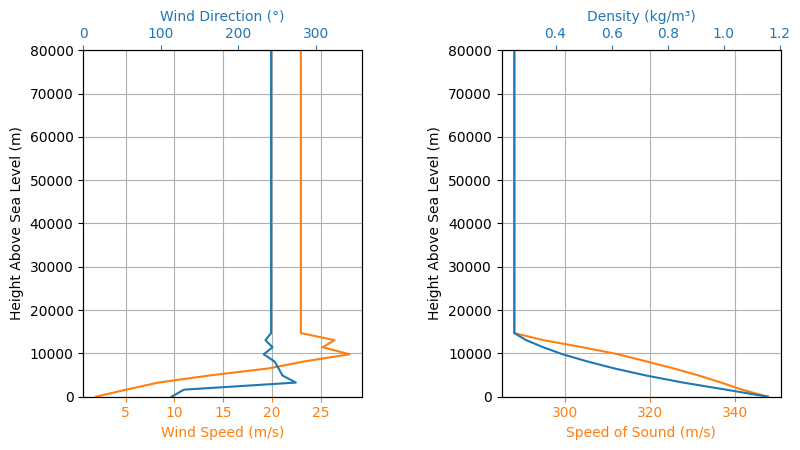


--- Gerando Gráficos Atmosféricos ---

Vento_Leste-Oeste: -1.79
Vento_Norte-Sul: 0.8


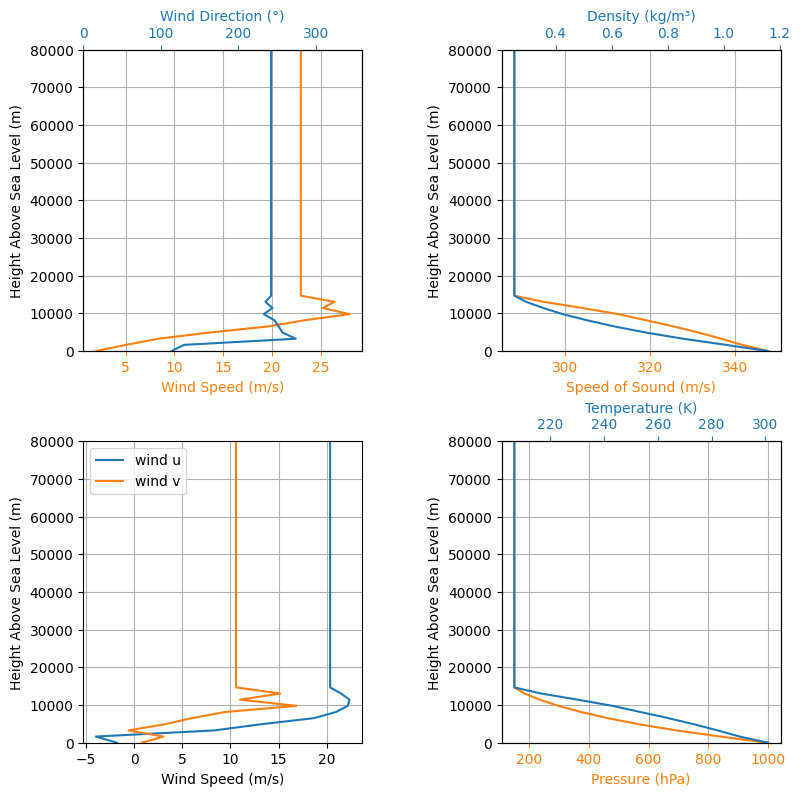


--- Ambiente de Lançamento configurado com sucesso ---
Configurando aerodinâmica externa unificada do DEIMOS II
Fonte de dados de arrasto selecionada: RASAero
Arquivo de arrasto carregado e suavizado via Spline: CD_Off_RASAero.csv e CD_On_RASAero.csv
Montando parâmetros estruturais do foguete (DeimosII_v4.0)
Acoplando o sistema de propulsão interno (BATES)
Adicionando superfícies aerodinâmicas (Coifa, Boattail, Aletas e Guias)

Configurando o Sistema de Recuperação...
Paraquedas MAIN configurado (Nominal: Apogeu | Lag Fixo: 5.5 s).

--- Resumo do Foguete ---

Identification of the AeroSurface:
----------------------------------
Name: Coifa_Eliptica
Python Class: <class 'rocketpy.rocket.aero_surface.nose_cone.NoseCone'>

Geometric information of NoseCone:
----------------------------------
Length: 0.098 m
Kind: elliptical
Base radius: 0.034 m
Reference rocket radius: 0.034 m
Reference radius ratio: 1.000

Lift information of the AeroSurface:
-----------------------------------
Center o

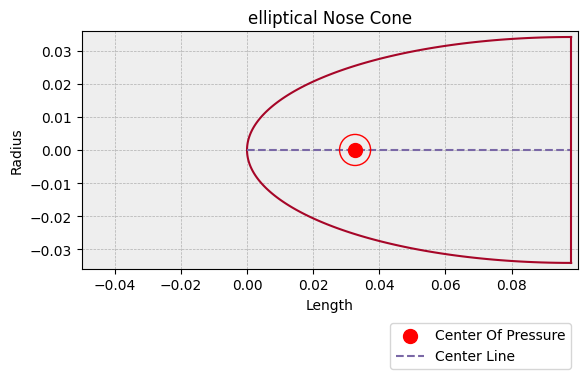

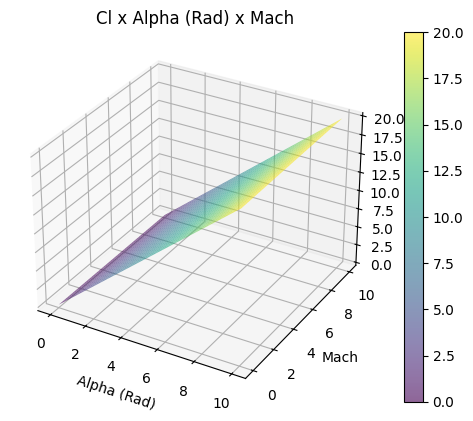

Identification of the AeroSurface:
----------------------------------
Name: Fins
Python Class: <class 'rocketpy.rocket.aero_surface.fins.trapezoidal_fins.TrapezoidalFins'>

Geometric information of the fin set:
-------------------------------------
Number of fins: 3
Reference rocket radius: 0.034 m
Tip chord: 0.036 m
Root chord: 0.100 m
Span: 0.089 m
Cant angle: 0.000 ° or 0.000 rad
Longitudinal section area: 0.006 m²
Aspect ratio: 2.622 
Gamma_c: 0.779 m
Mean aerodynamic chord: 0.037 m

Roll information of the fin set:
--------------------------------
Geometric constant: 0.000 m
Damping interference factor: 1.158 rad
Forcing interference factor: 0.937 rad

Lift information of the fin set:
--------------------------------
Lift interference factor: 1.277 m
Center of Pressure position in local coordinates: (0.000, 0.000, 0.069)
Lift Coefficient derivative (single fin) at Mach 0 and AoA 0: 4.387


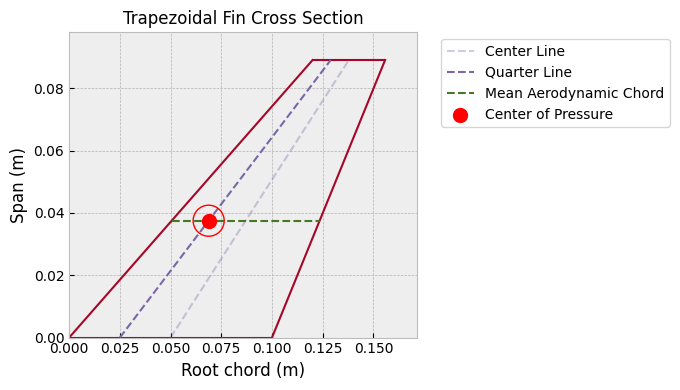

Roll parameters:


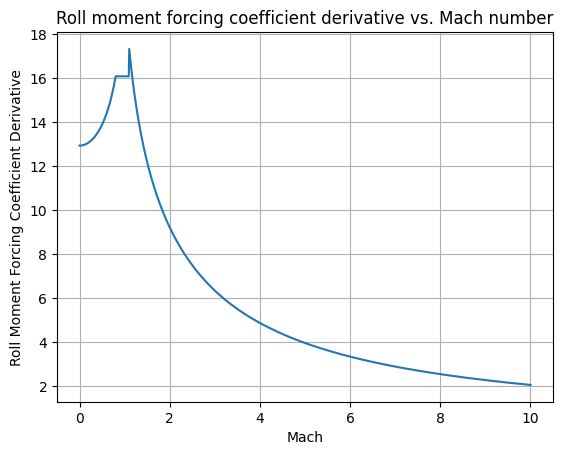

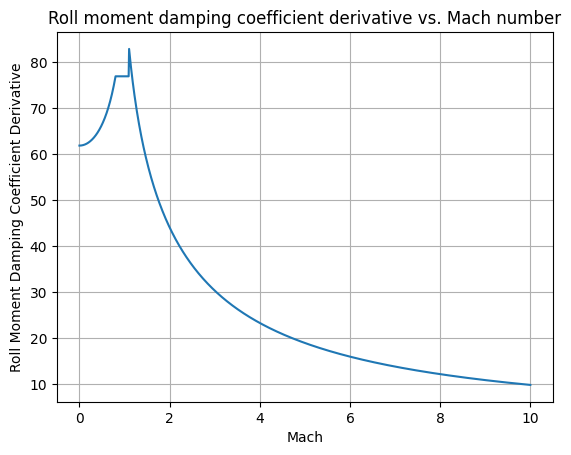

Lift coefficient:


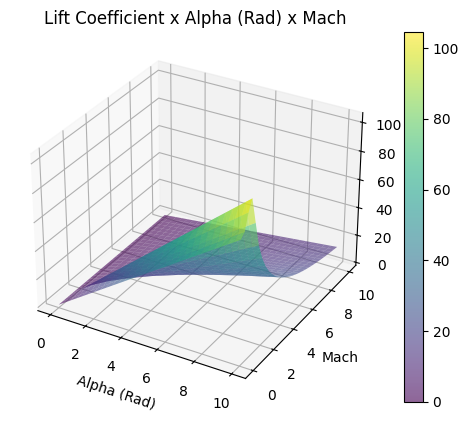

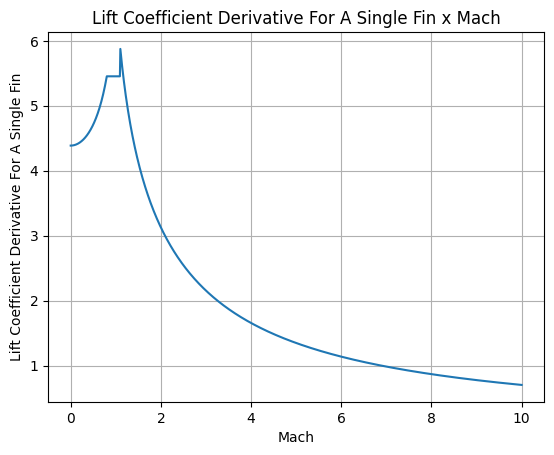

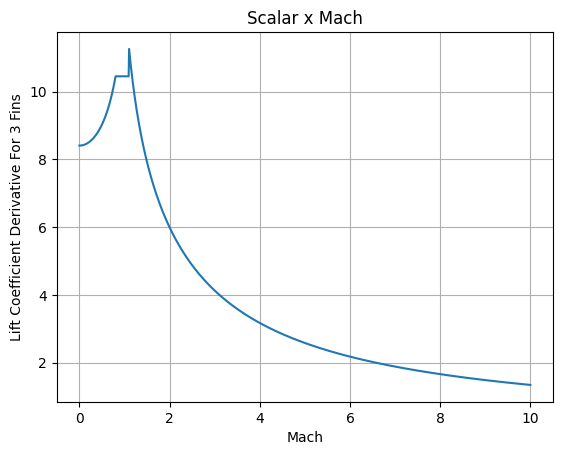

Identification of the AeroSurface:
----------------------------------
Name: Boat Tail (Semi-Triangular)
Python Class: <class 'rocketpy.rocket.aero_surface.tail.Tail'>

Geometric information of the Tail:
----------------------------------
Top radius: 0.034 m
Bottom radius: 0.024 m
Reference radius: 0.068 m
Length: 0.066 m
Slant length: 0.067 m
Surface area: 0.012162 m²

Lift information of the AeroSurface:
-----------------------------------
Center of Pressure position in local coordinates: (0.000, 0.000, 0.031)
Lift coefficient derivative at Mach 0 and AoA 0: -1.029 1/rad



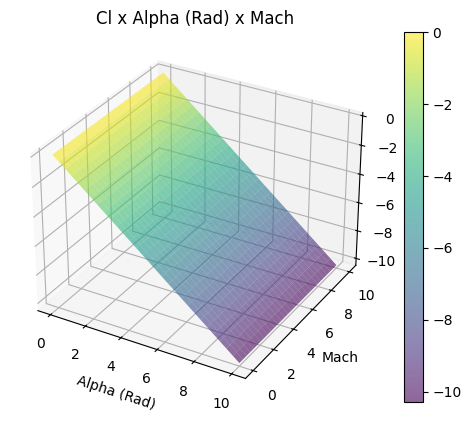

Identification of the AeroSurface:
----------------------------------
Name: Rail Buttons
Python Class: <class 'rocketpy.rocket.aero_surface.rail_buttons.RailButtons'>

Geometric information of the RailButtons:
-----------------------------------------
Distance from one button to the other: 0.780 m
Angular position of the buttons: 180.000 deg

Lift information of the AeroSurface:
-----------------------------------
Center of Pressure position in local coordinates: (0.000, 0.000, 0.000)
Lift coefficient derivative at Mach 0 and AoA 0: 0.000 1/rad


Parachute Details

Parachute Main with a cd_s of 1.5610 m2
Ejection signal trigger: At Apogee
Ejection system refresh rate: 33.000 Hz
Time between ejection signal is triggered and the parachute is fully opened: 5.5 s


--- Resumo do Voo ---


Inertia Details

Rocket Mass: 2.790 kg (without motor)
Rocket Dry Mass: 3.300 kg (with unloaded motor)
Rocket Loaded Mass: 3.923 kg
Rocket Structural Mass Ratio: 0.841
Rocket Inertia (with unloaded motor)

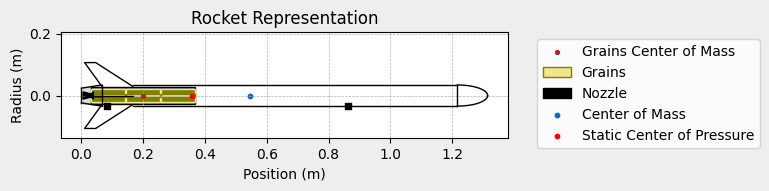


Mass Plots
----------------------------------------


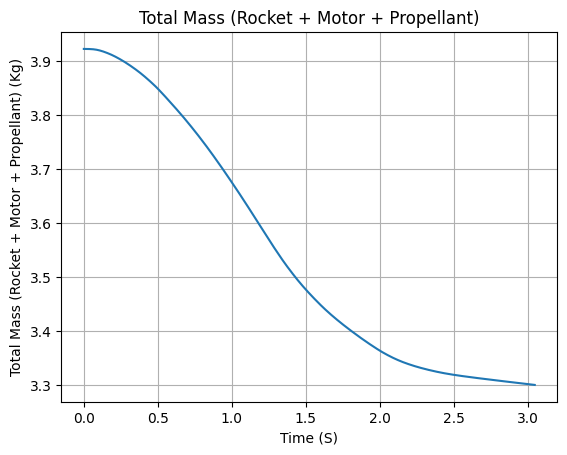

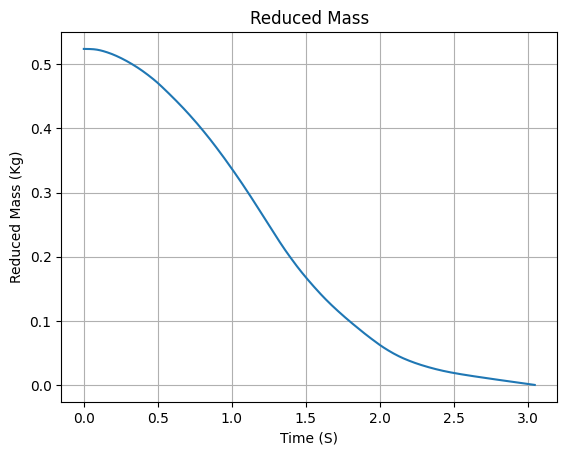


Aerodynamics Plots
----------------------------------------
Drag Plots
--------------------


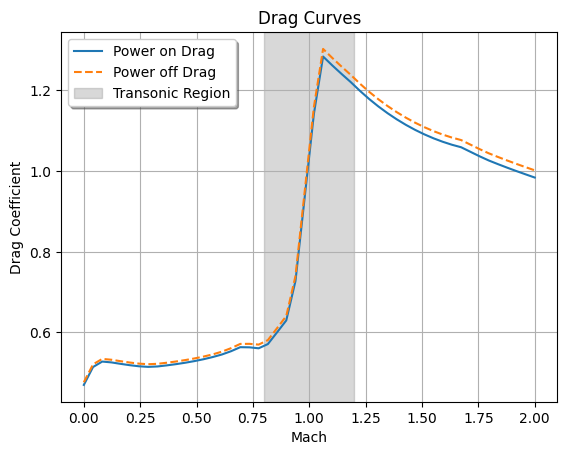


Stability Plots
--------------------


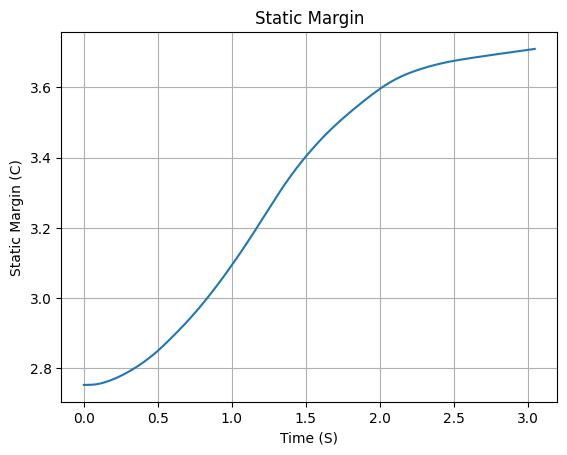

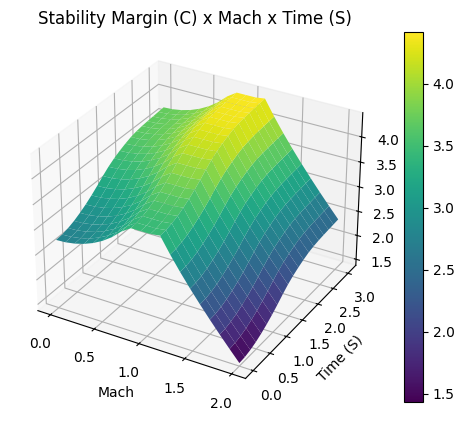


Thrust-to-Weight Plot
----------------------------------------


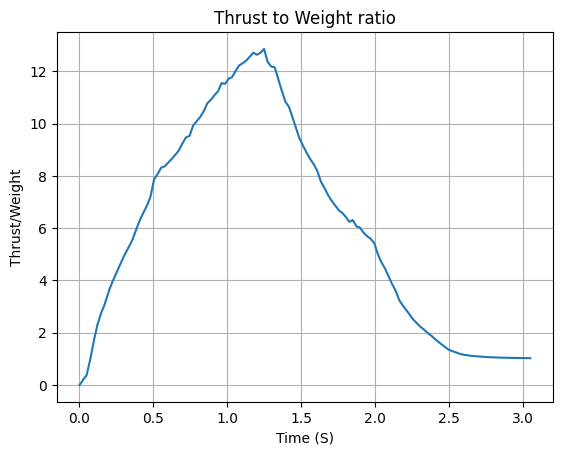


########################################
  RELATÓRIO FINAL DE VOO (POST-FLIGHT)  
########################################
Apogeu ASL: 1515.58 m
Apogeu AGL: 1022.58 m
Tempo de apogeu: 14.99 s
Velocidade máxima: 142.87 m/s
Aceleração máxima (valor alto devido a abertura do paraquedas): 515.86 m/s²
Mach máximo: 0.412 Mach
Velocidade na saída do trilho: 18.43 m/s
Estabilidade na saída de base: 2.87 cal
Altitude 2 s depois do apogeu: 1003.15 m
Velocidade de pouso: -6.08 m/s
Duração total do ascenção: 14.99 s
Duração completa do voo: 160.48 s

Initial Conditions

Initial time: 0.000 s
Position - x: 0.00 m | y: 0.00 m | z: 493.00 m
Velocity - Vx: 0.00 m/s | Vy: 0.00 m/s | Vz: 0.00 m/s
Attitude (quaternions) - e0: 0.258 | e1: 0.023 | e2: -0.084 | e3: -0.962
Euler Angles - Spin φ : -180.00° | Nutation θ: -10.00° | Precession ψ: 30.00°
Angular Velocity - ω1: 0.00 rad/s | ω2: 0.00 rad/s | ω3: 0.00 rad/s
Initial Stability Margin: 2.753 c


Surface Wind Conditions

Frontal Surface Wind Speed: 1.5

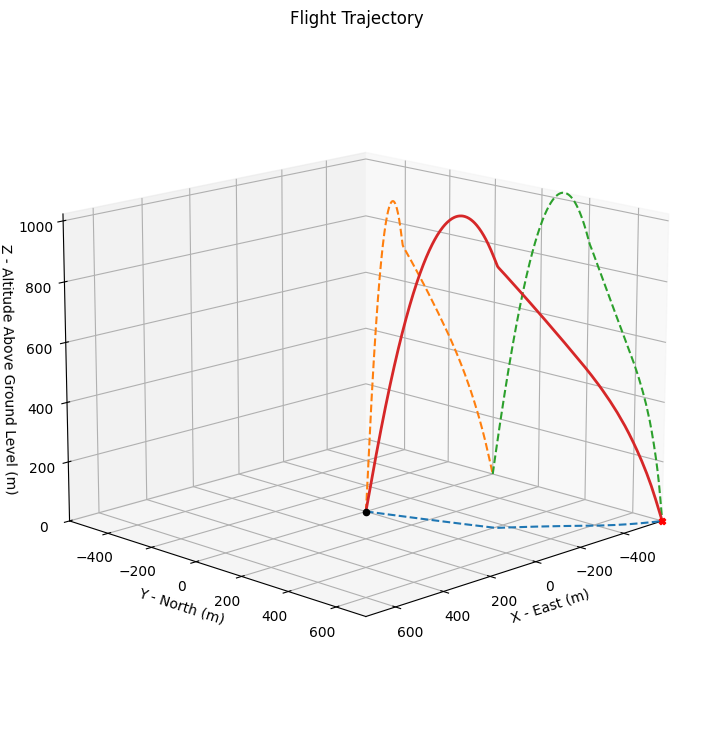



Trajectory Kinematic Plots



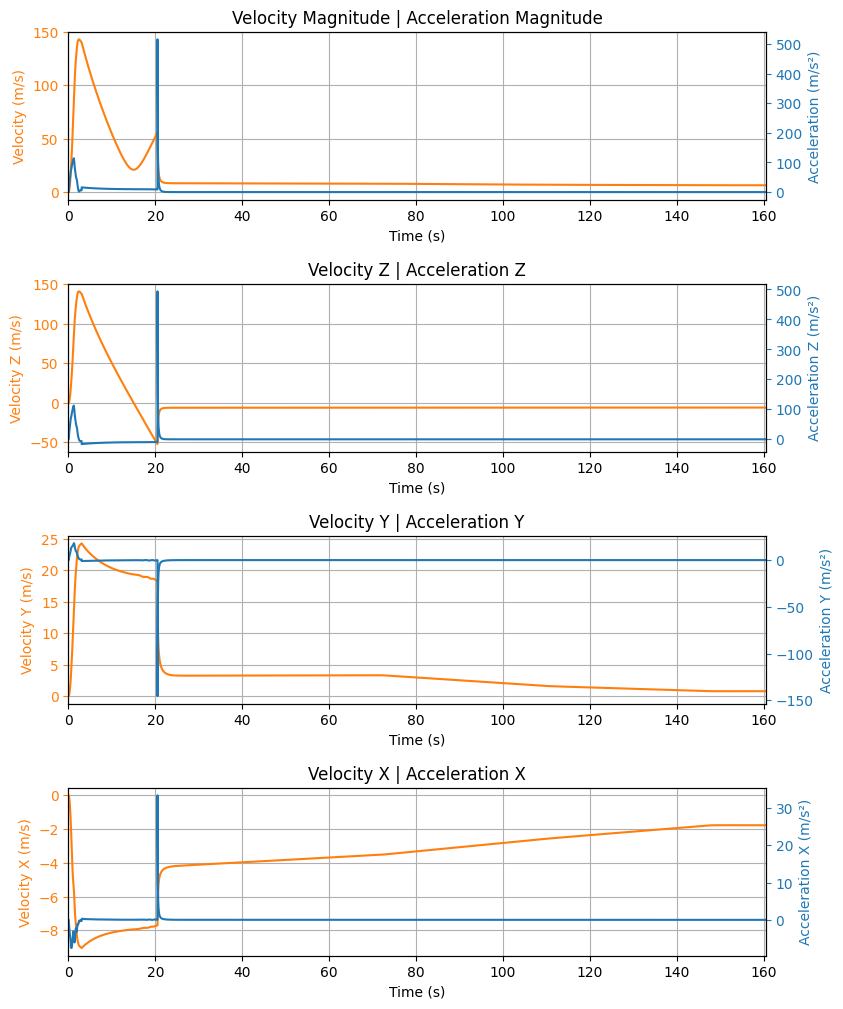



Angular Position Plots



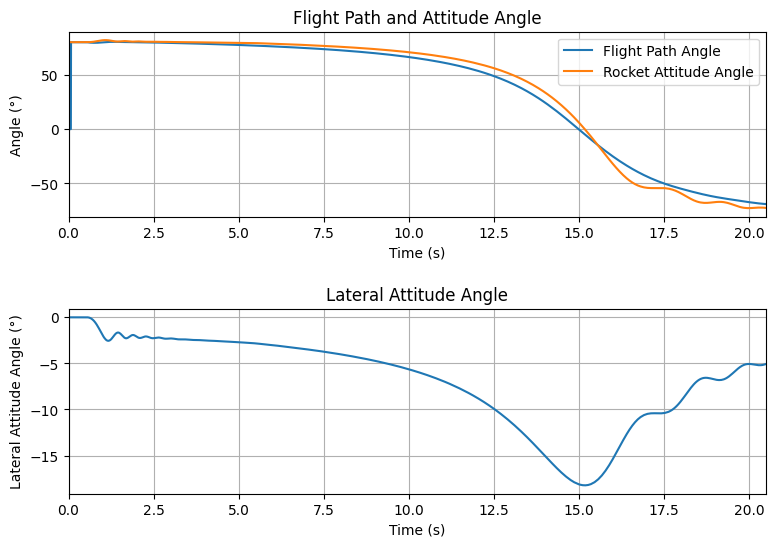



Path, Attitude and Lateral Attitude Angle Plots



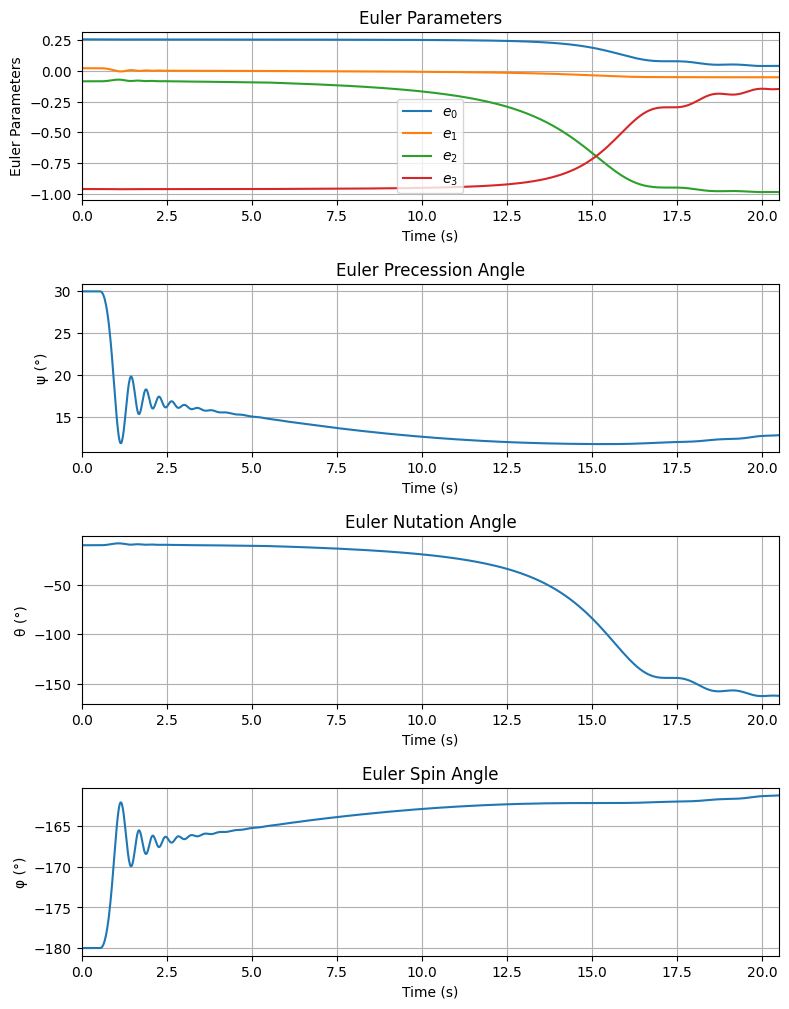



Trajectory Angular Velocity and Acceleration Plots



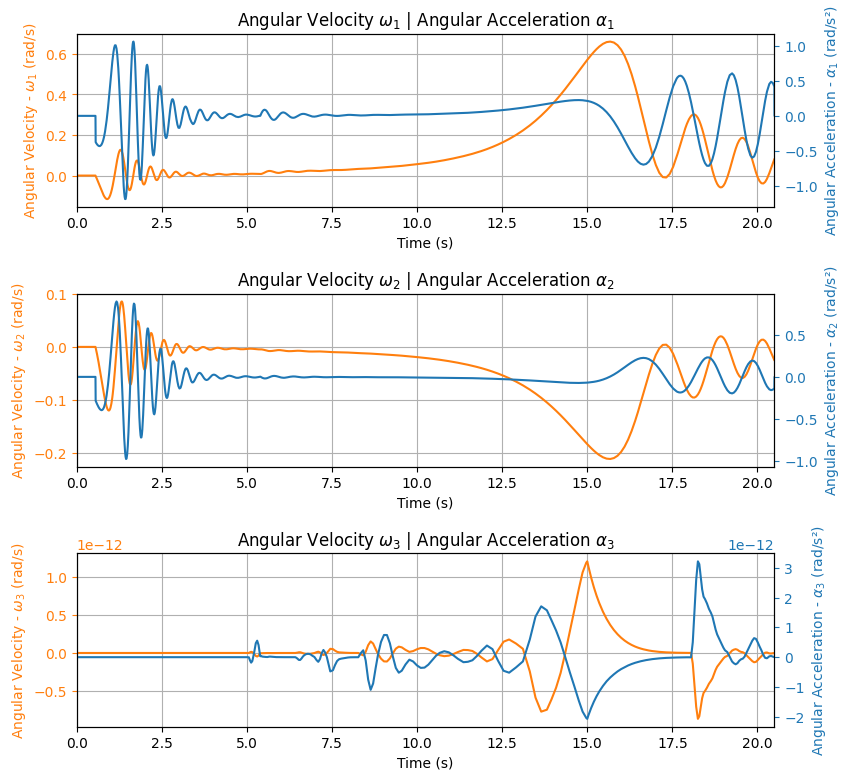



Aerodynamic Forces Plots



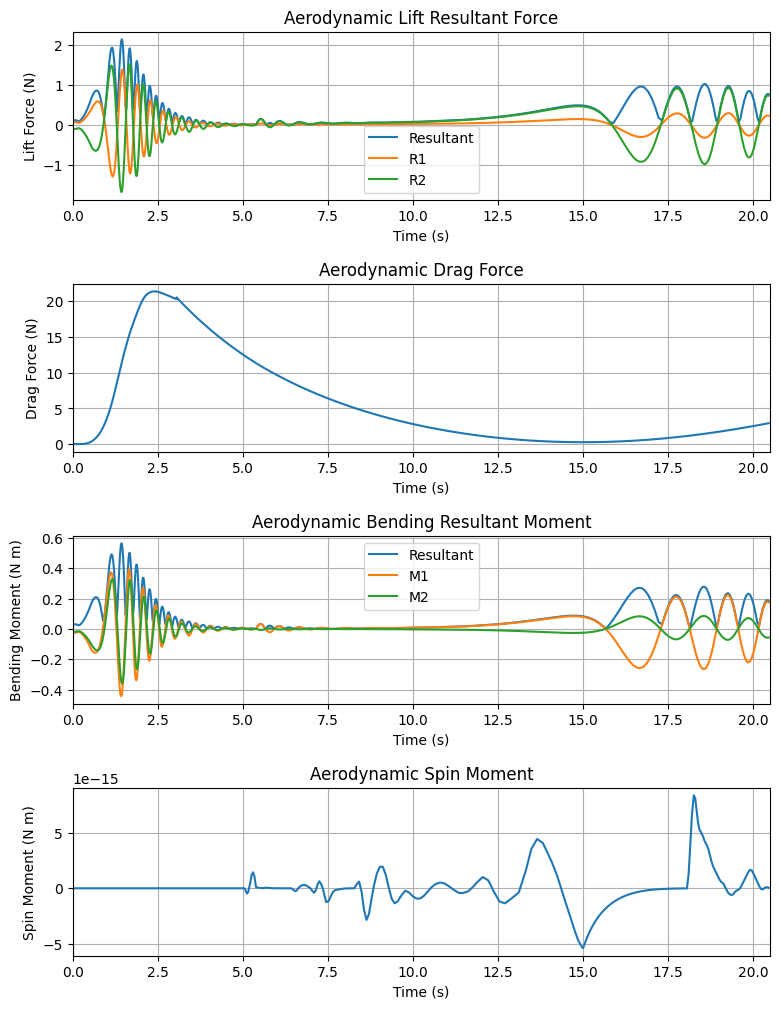

Rail button height not defined. Skipping bending moment plots.




Rail Buttons Bending Moments Plots



Rail Buttons Forces Plots



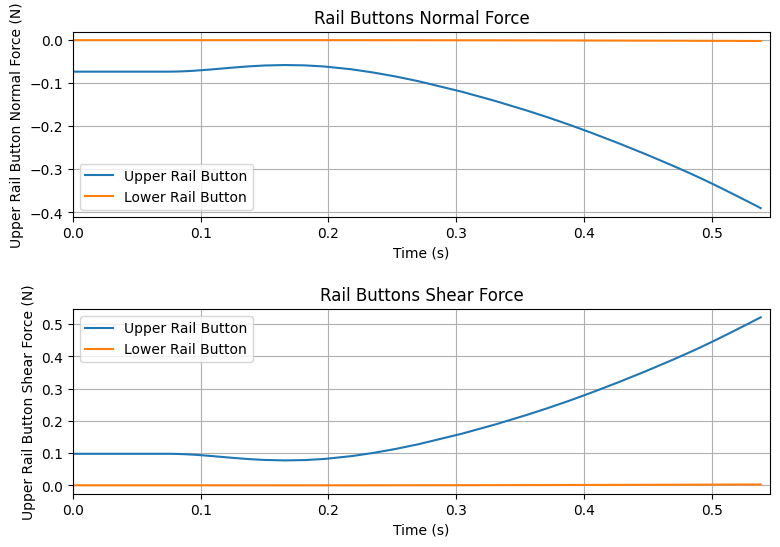



Trajectory Energy Plots



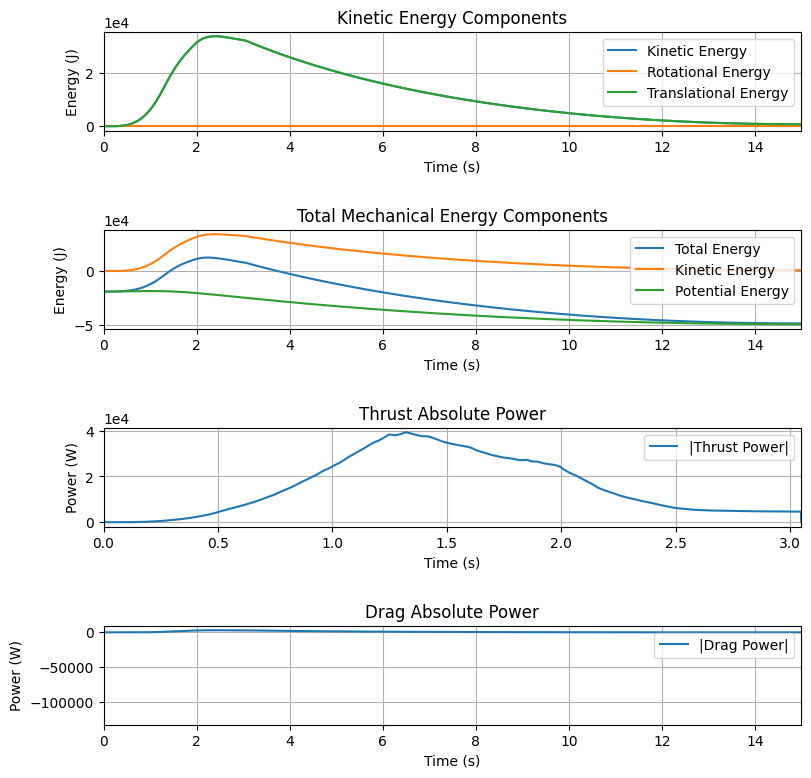



Trajectory Fluid Mechanics Plots



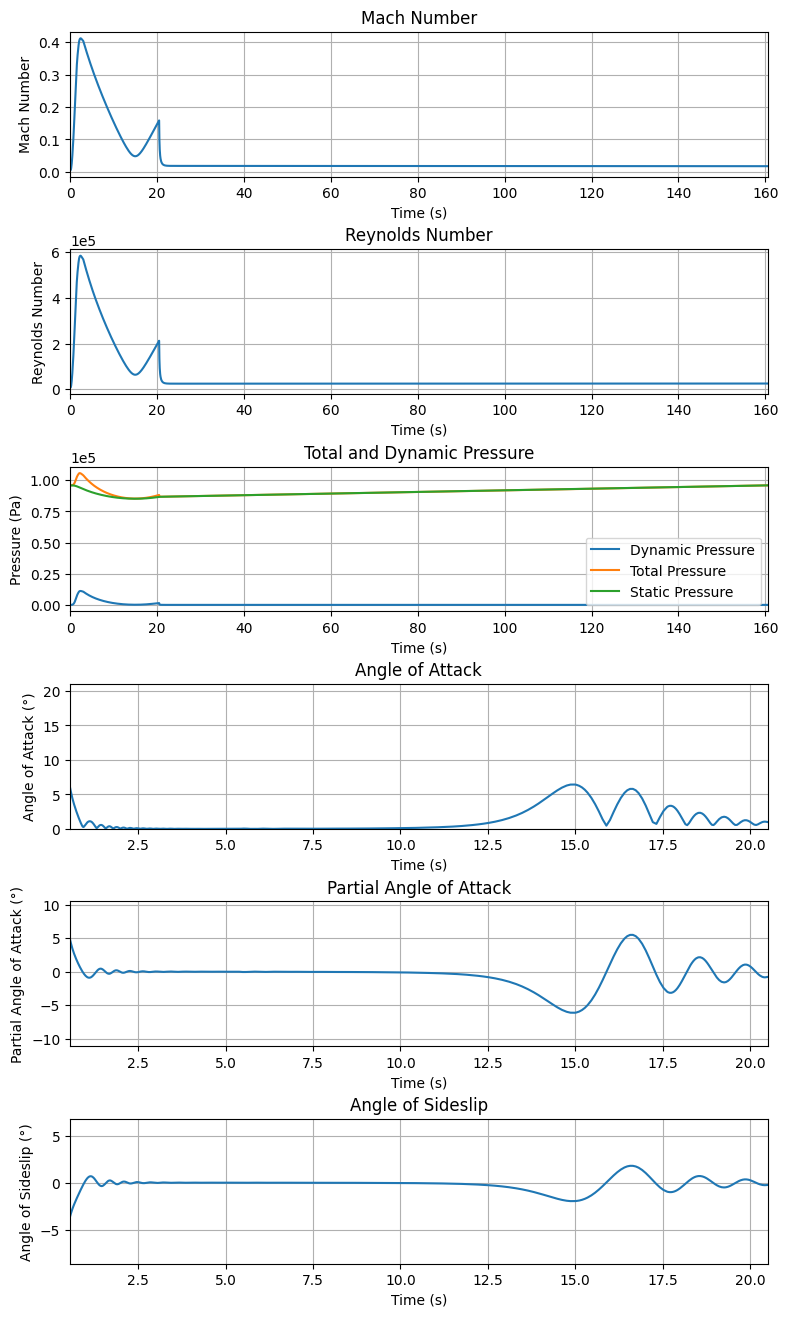



Trajectory Stability and Control Plots



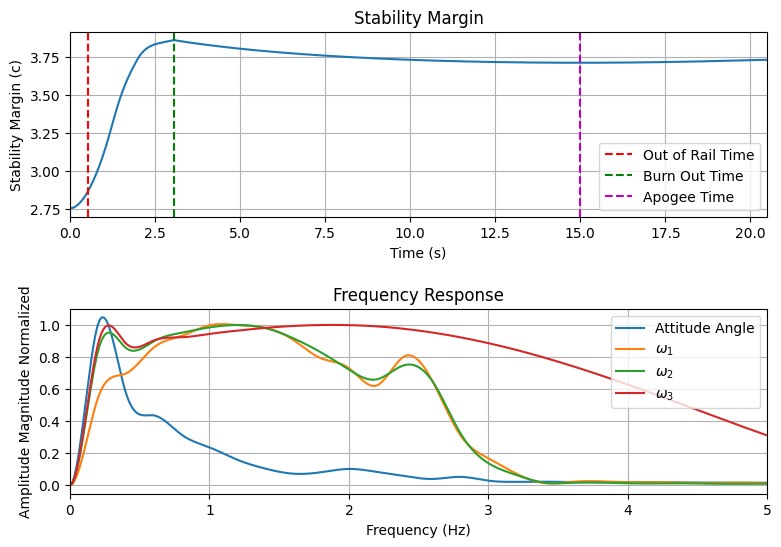



Rocket and Parachute Pressure Plots



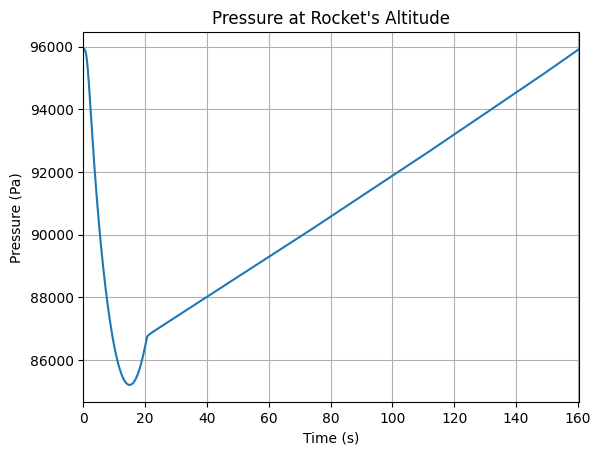

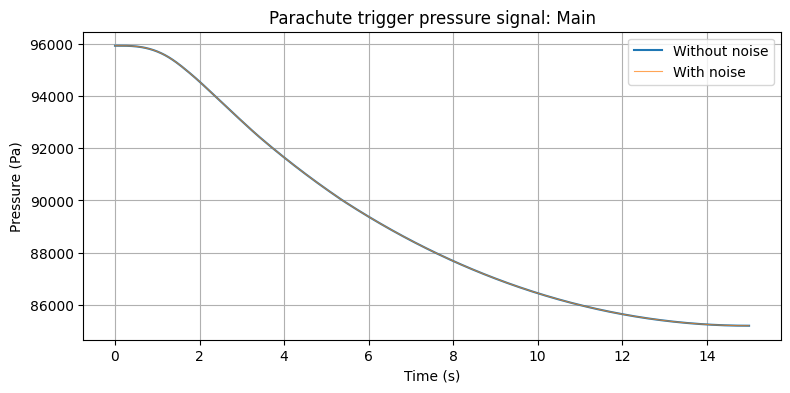


Pipeline executado sem falhas. Dados consolidados.


In [36]:
env = set_env(days_to_launch = LAUNCH_DAYS_FROM_NOW, hour = LAUNCH_HOUR, atm_type = "Windy", atm_file = "ECMWF", max_altitude = 1800, datum = "SIRGAS2000", verbose = False)
deimos_ii = set_rocket(motor_type = "BATES", flight_case = "nominal", lag_paraquedas = 3.5, custom_altitude = 300, drag_source = "RASAero", verbose = False, return_structure = False)
flight_custom = set_flight(motor_type = "BATES", flight_case = "nominal", lag_paraquedas = 3.5, custom_altitude = 300, drag_source = "RASAero", verbose = True)


      INICIANDO PIPELINE DE SIMULAÇÃO INTEGRADA      
Configurando ambiente para daqui a 5 dias à(s) 8 h
Baixando dados atmosféricos via Windy (Modelo: ECMWF)
Carregando perfil topográfico e limitando altitude para 1800 m
Elevação da base definida para: 493.00 metros ASL.

--- Resumo do Ambiente ---

Gravity Details

Acceleration of gravity at surface level:    9.7860 m/s²
Acceleration of gravity at  14.247 km (ASL): 9.7437 m/s²


Launch Site Details

Launch Date: 2026-09-03 11:00:00 UTC | 2026-09-03 08:00:00 America/Sao_Paulo
Launch Site Latitude: -21.94306°
Launch Site Longitude: -48.95243°
Reference Datum: SIRGAS2000
Launch Site UTM coordinates: 91629.47 W    7568206.38 S
Launch Site UTM zone: 23K
Launch Site Surface Elevation: 493.0 m


Atmospheric Model Details

Atmospheric Model Type: Windy
Windy Maximum Height: 14.247 km

Surface Atmospheric Conditions

Surface Wind Speed: 3.66 m/s
Surface Wind Direction: 137.66°
Surface Wind Heading: 317.66°
Surface Pressure: 961.24 hPa
Surfac

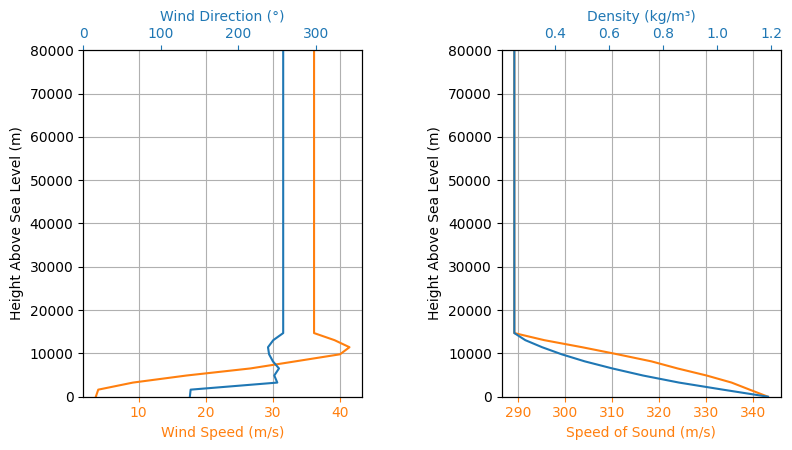


--- Gerando Gráficos Atmosféricos ---

Vento_Leste-Oeste: -2.44
Vento_Norte-Sul: 2.68


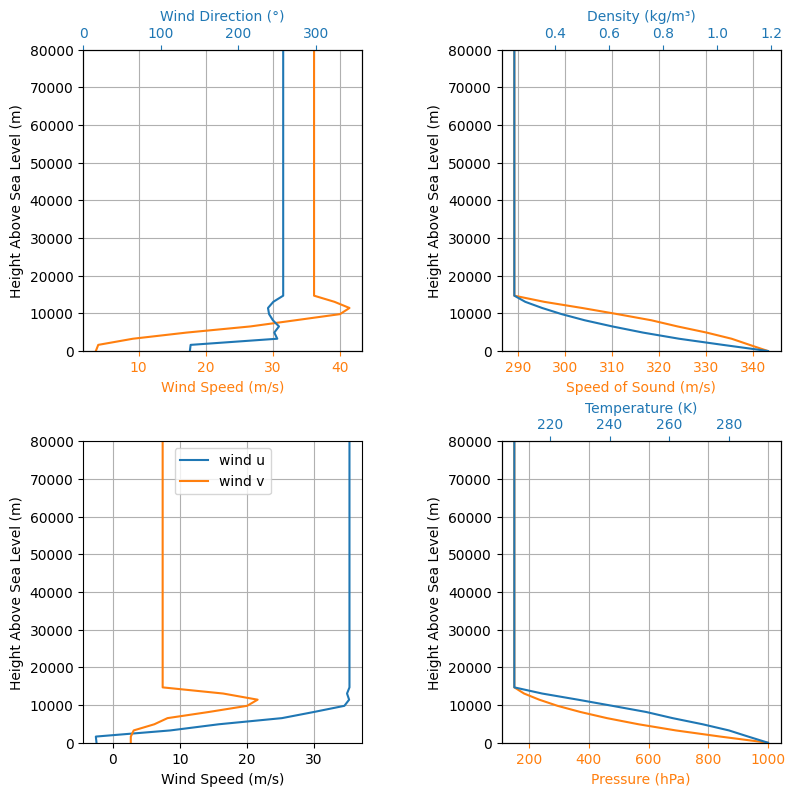


--- Ambiente de Lançamento configurado com sucesso ---
Configurando aerodinâmica externa unificada do DEIMOS II
Fonte de dados de arrasto selecionada: RASAero
Arquivo de arrasto carregado e suavizado via Spline: CD_Off_RASAero.csv e CD_On_RASAero.csv
Montando parâmetros estruturais do foguete (DeimosII_v4.0)
Acoplando o sistema de propulsão interno (BATES)
Adicionando superfícies aerodinâmicas (Coifa, Boattail, Aletas e Guias)

Configurando o Sistema de Recuperação...
Caso BALÍSTICO: Nenhum paraquedas será acionado no Deimos II.

--- Resumo do Foguete ---

Identification of the AeroSurface:
----------------------------------
Name: Coifa_Eliptica
Python Class: <class 'rocketpy.rocket.aero_surface.nose_cone.NoseCone'>

Geometric information of NoseCone:
----------------------------------
Length: 0.098 m
Kind: elliptical
Base radius: 0.034 m
Reference rocket radius: 0.034 m
Reference radius ratio: 1.000

Lift information of the AeroSurface:
-----------------------------------
Center of P

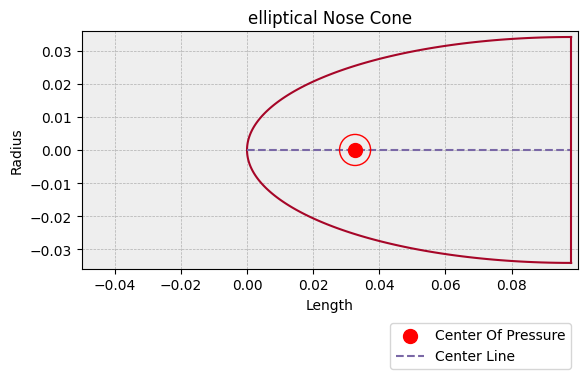

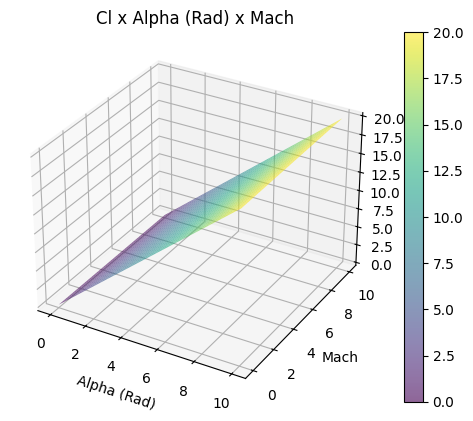

Identification of the AeroSurface:
----------------------------------
Name: Fins
Python Class: <class 'rocketpy.rocket.aero_surface.fins.trapezoidal_fins.TrapezoidalFins'>

Geometric information of the fin set:
-------------------------------------
Number of fins: 3
Reference rocket radius: 0.034 m
Tip chord: 0.036 m
Root chord: 0.100 m
Span: 0.089 m
Cant angle: 0.000 ° or 0.000 rad
Longitudinal section area: 0.006 m²
Aspect ratio: 2.622 
Gamma_c: 0.779 m
Mean aerodynamic chord: 0.037 m

Roll information of the fin set:
--------------------------------
Geometric constant: 0.000 m
Damping interference factor: 1.158 rad
Forcing interference factor: 0.937 rad

Lift information of the fin set:
--------------------------------
Lift interference factor: 1.277 m
Center of Pressure position in local coordinates: (0.000, 0.000, 0.069)
Lift Coefficient derivative (single fin) at Mach 0 and AoA 0: 4.387


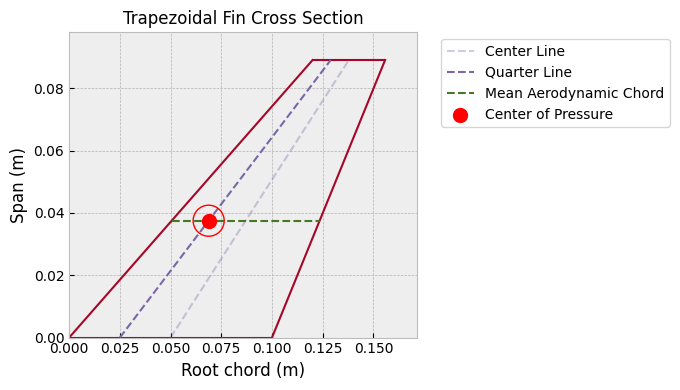

Roll parameters:


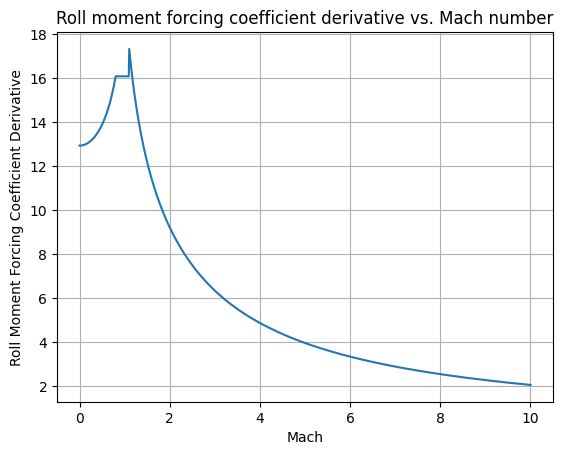

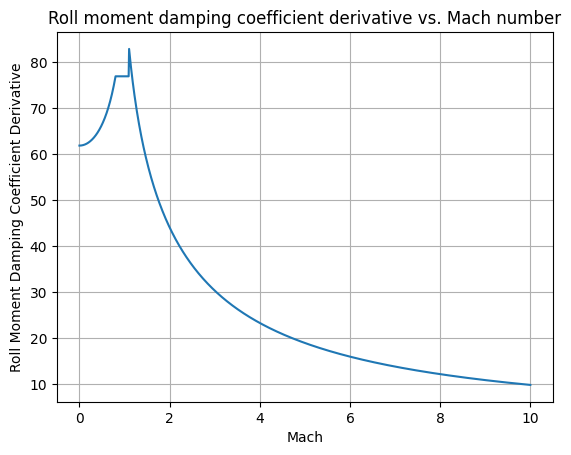

Lift coefficient:


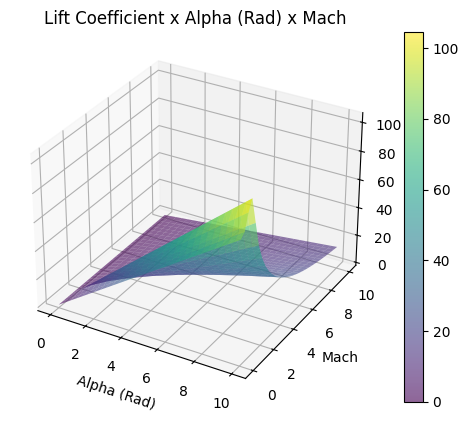

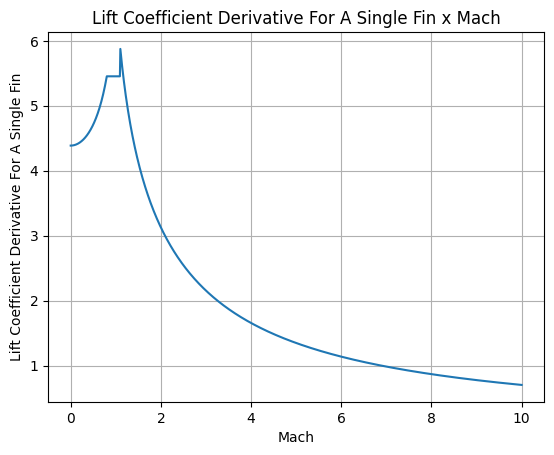

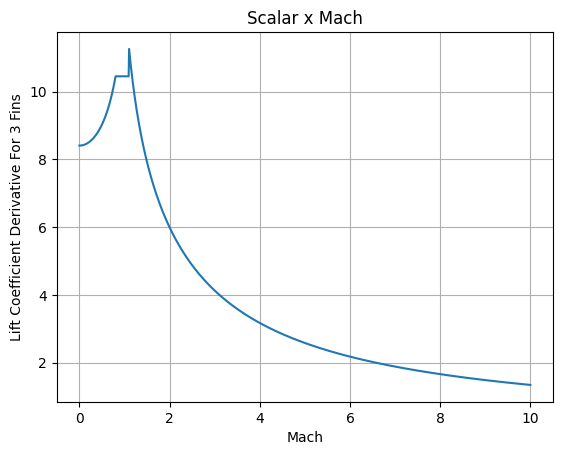

Identification of the AeroSurface:
----------------------------------
Name: Boat Tail (Semi-Triangular)
Python Class: <class 'rocketpy.rocket.aero_surface.tail.Tail'>

Geometric information of the Tail:
----------------------------------
Top radius: 0.034 m
Bottom radius: 0.024 m
Reference radius: 0.068 m
Length: 0.066 m
Slant length: 0.067 m
Surface area: 0.012162 m²

Lift information of the AeroSurface:
-----------------------------------
Center of Pressure position in local coordinates: (0.000, 0.000, 0.031)
Lift coefficient derivative at Mach 0 and AoA 0: -1.029 1/rad



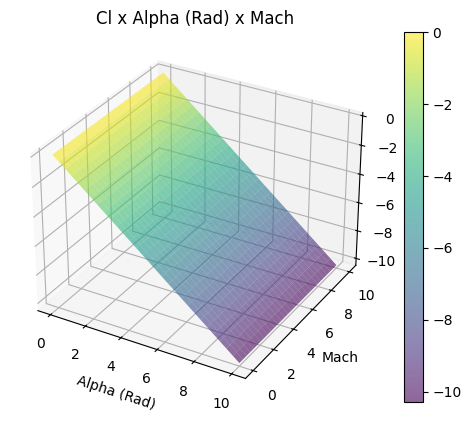

Identification of the AeroSurface:
----------------------------------
Name: Rail Buttons
Python Class: <class 'rocketpy.rocket.aero_surface.rail_buttons.RailButtons'>

Geometric information of the RailButtons:
-----------------------------------------
Distance from one button to the other: 0.780 m
Angular position of the buttons: 180.000 deg

Lift information of the AeroSurface:
-----------------------------------
Center of Pressure position in local coordinates: (0.000, 0.000, 0.000)
Lift coefficient derivative at Mach 0 and AoA 0: 0.000 1/rad


--- Resumo do Voo ---


Inertia Details

Rocket Mass: 2.790 kg (without motor)
Rocket Dry Mass: 3.300 kg (with unloaded motor)
Rocket Loaded Mass: 3.923 kg
Rocket Structural Mass Ratio: 0.841
Rocket Inertia (with unloaded motor) 11: 0.370 kg*m2
Rocket Inertia (with unloaded motor) 22: 0.370 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.003 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.

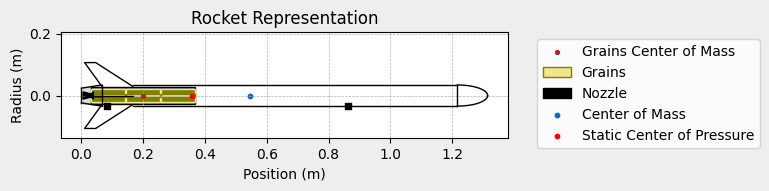


Mass Plots
----------------------------------------


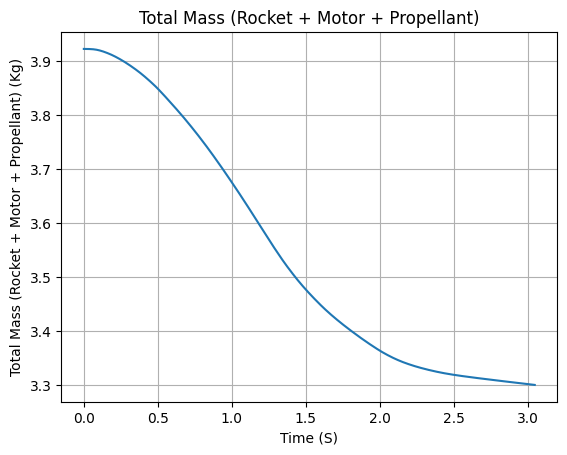

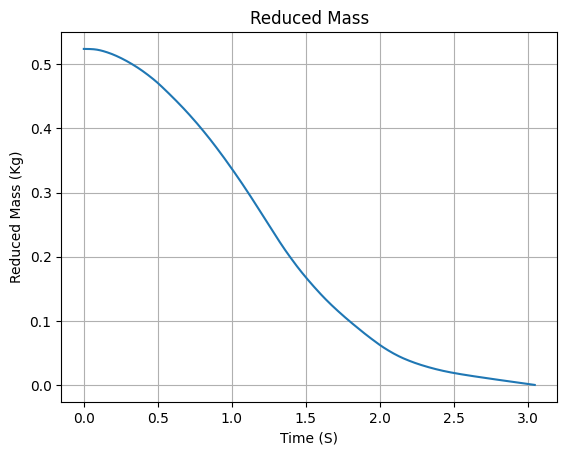


Aerodynamics Plots
----------------------------------------
Drag Plots
--------------------


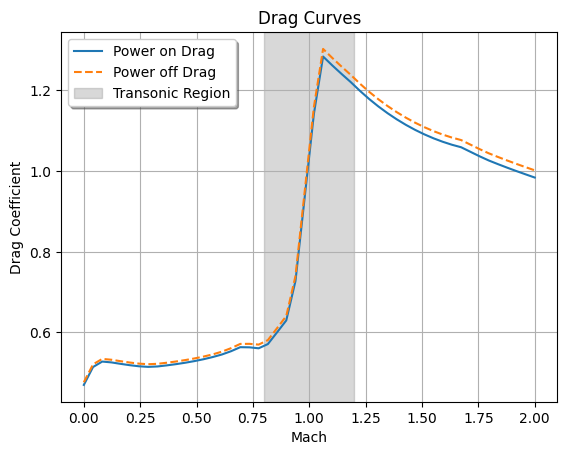


Stability Plots
--------------------


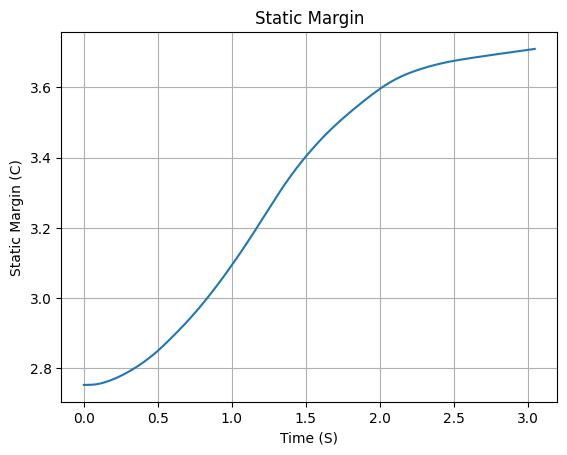

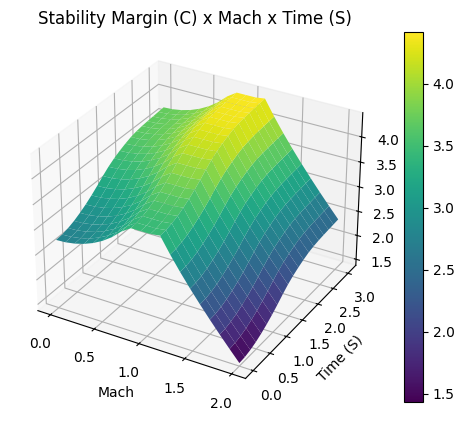


Thrust-to-Weight Plot
----------------------------------------


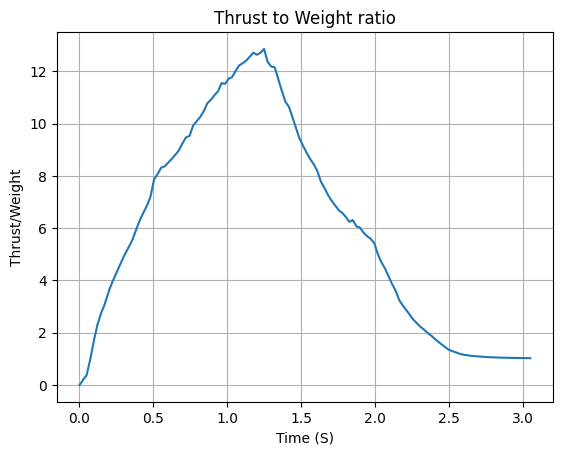


########################################
  RELATÓRIO FINAL DE VOO (POST-FLIGHT)  
########################################
Apogeu ASL: 1521.82 m
Apogeu AGL: 1028.82 m
Tempo de apogeu: 15.03 s
Velocidade máxima: 142.49 m/s
Aceleração máxima: 113.64 m/s²
Mach máximo: 0.416 Mach
Velocidade na saída do trilho: 18.43 m/s
Estabilidade na saída de base: 2.87 cal
Altitude 2 s depois do apogeu: 1009.59 m
Velocidade de pouso: -121.16 m/s
Duração total do ascenção: 15.03 s
Duração completa do voo: 30.36 s

Initial Conditions

Initial time: 0.000 s
Position - x: 0.00 m | y: 0.00 m | z: 493.00 m
Velocity - Vx: 0.00 m/s | Vy: 0.00 m/s | Vz: 0.00 m/s
Attitude (quaternions) - e0: 0.258 | e1: 0.023 | e2: -0.084 | e3: -0.962
Euler Angles - Spin φ : -180.00° | Nutation θ: -10.00° | Precession ψ: 30.00°
Angular Velocity - ω1: 0.00 rad/s | ω2: 0.00 rad/s | ω3: 0.00 rad/s
Initial Stability Margin: 2.753 c


Surface Wind Conditions

Frontal Surface Wind Speed: 3.57 m/s
Lateral Surface Wind Speed: 0.78 m/s



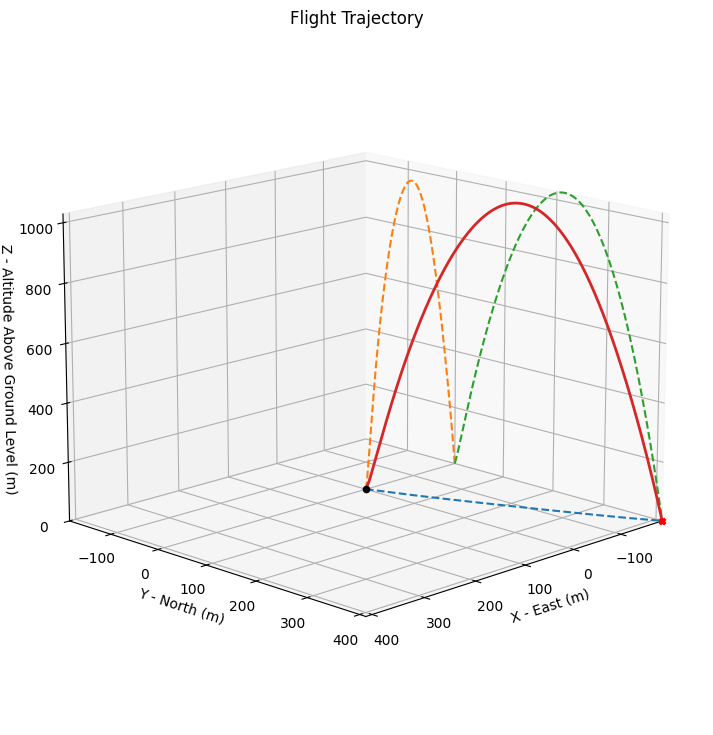



Trajectory Kinematic Plots



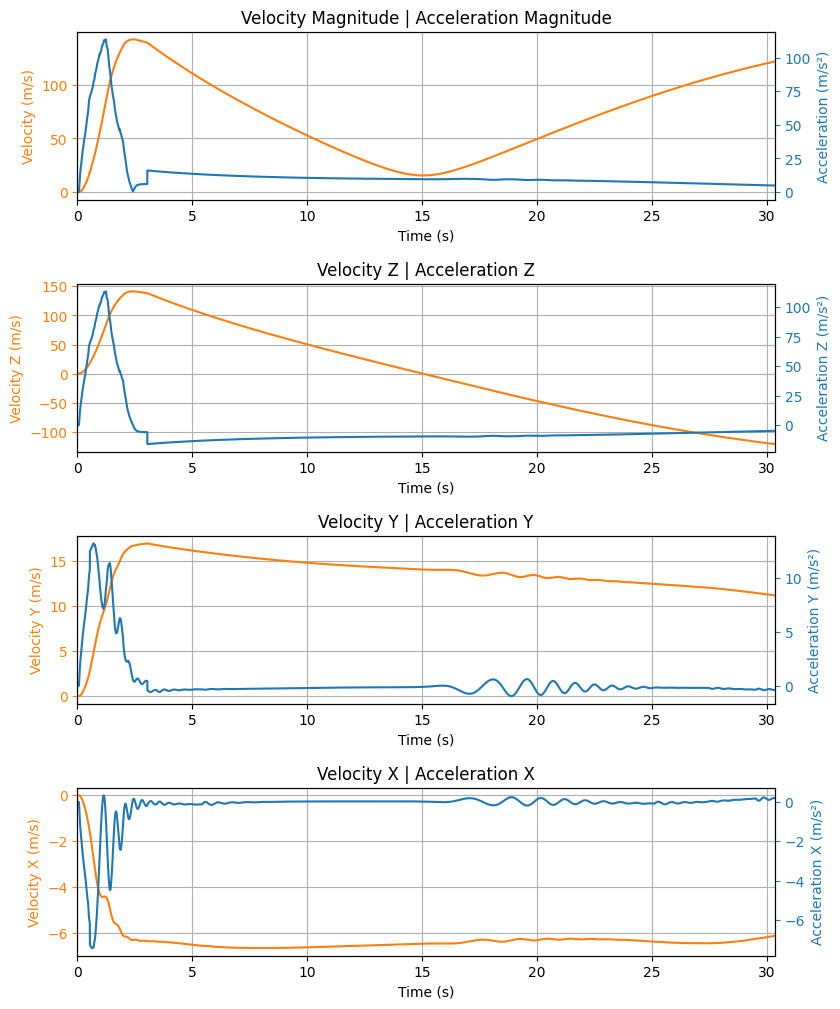



Angular Position Plots



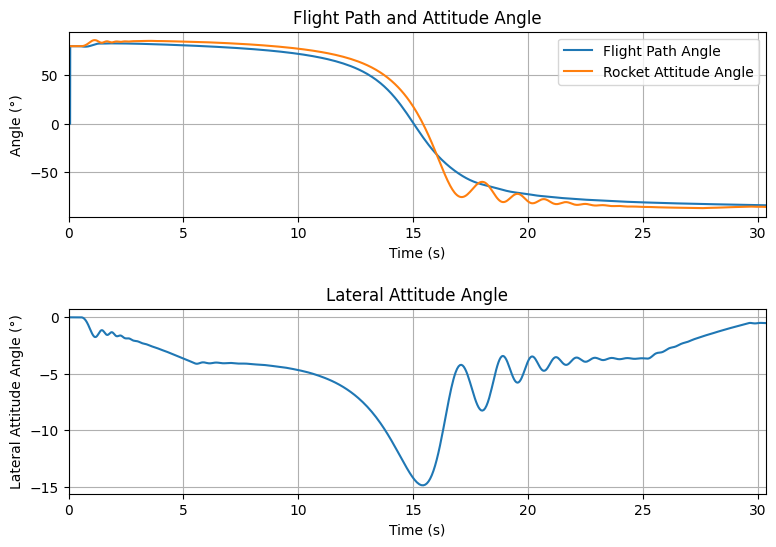



Path, Attitude and Lateral Attitude Angle Plots



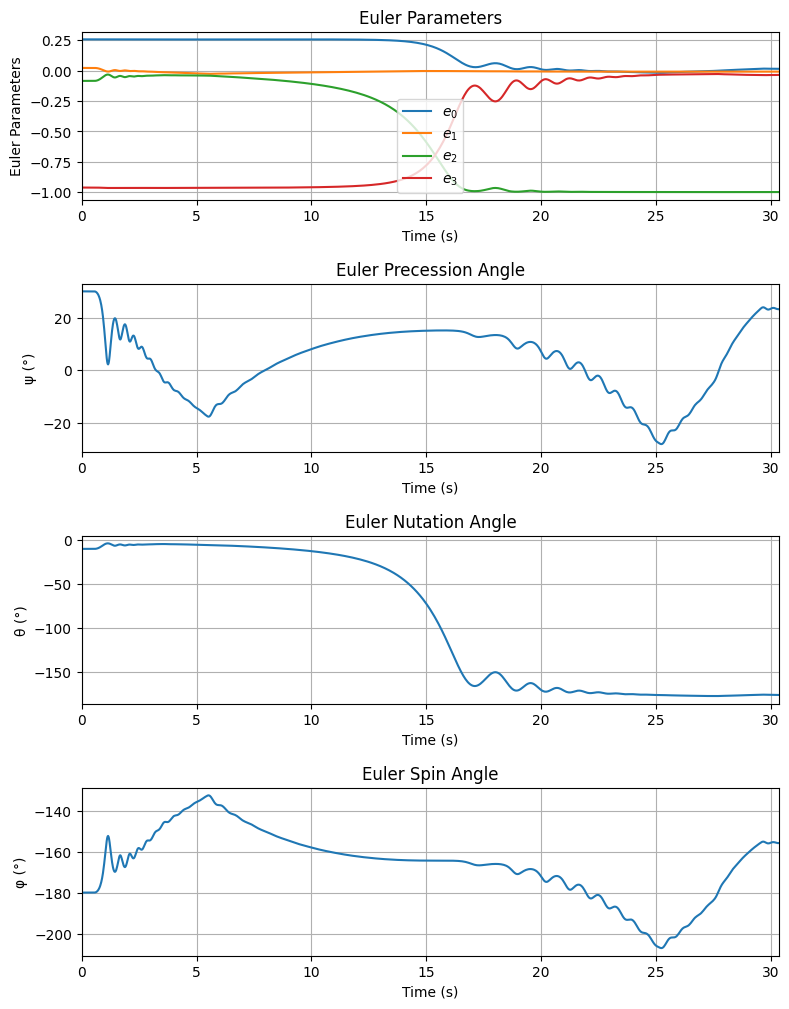



Trajectory Angular Velocity and Acceleration Plots



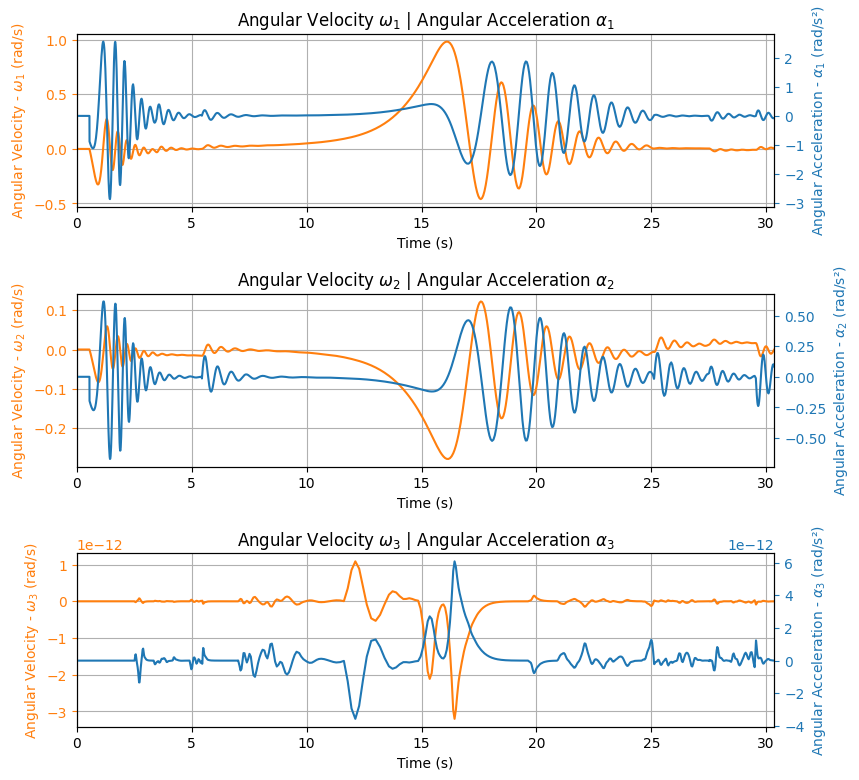



Aerodynamic Forces Plots



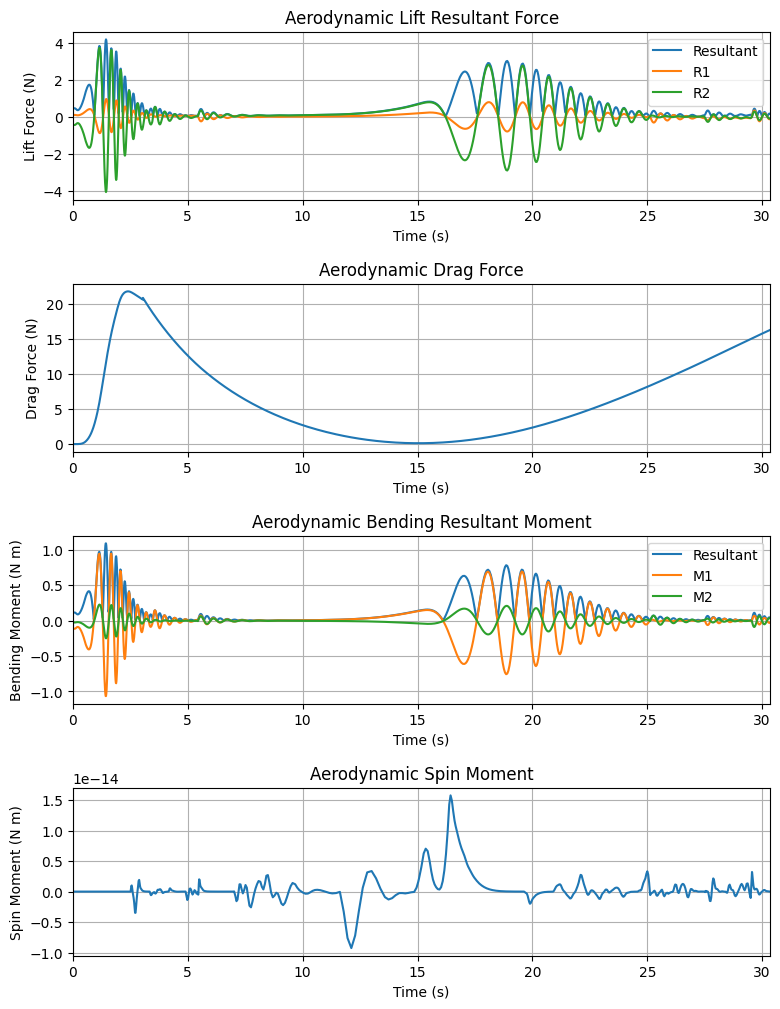

Rail button height not defined. Skipping bending moment plots.




Rail Buttons Bending Moments Plots



Rail Buttons Forces Plots



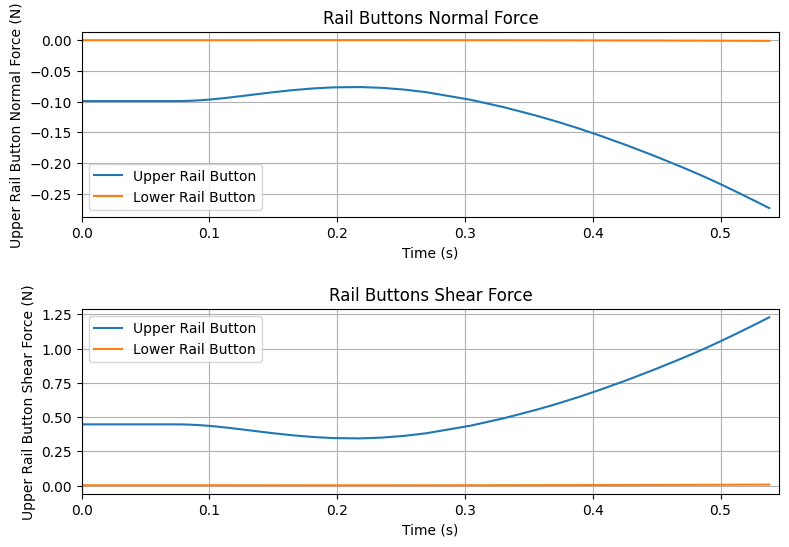



Trajectory Energy Plots



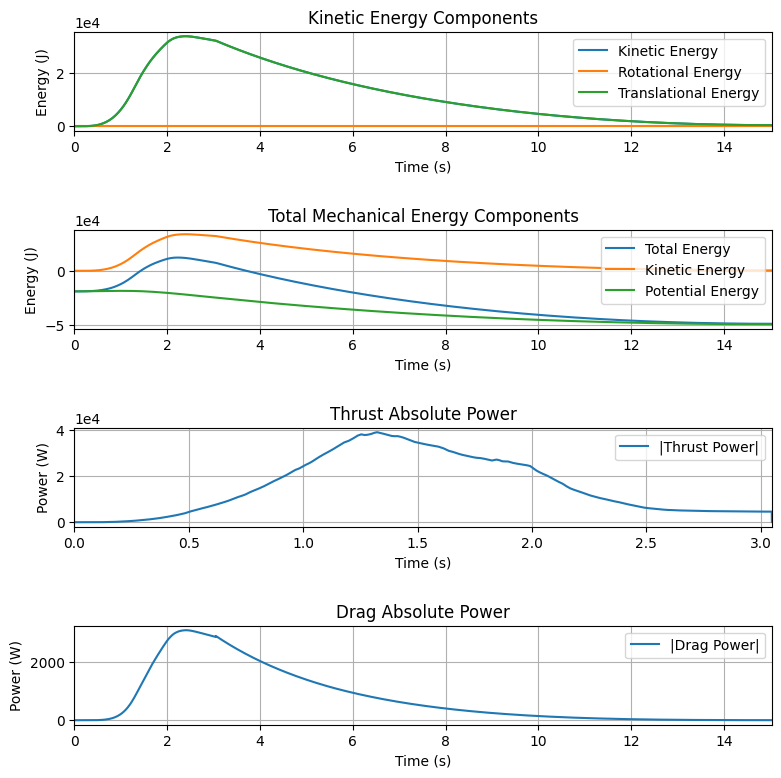



Trajectory Fluid Mechanics Plots



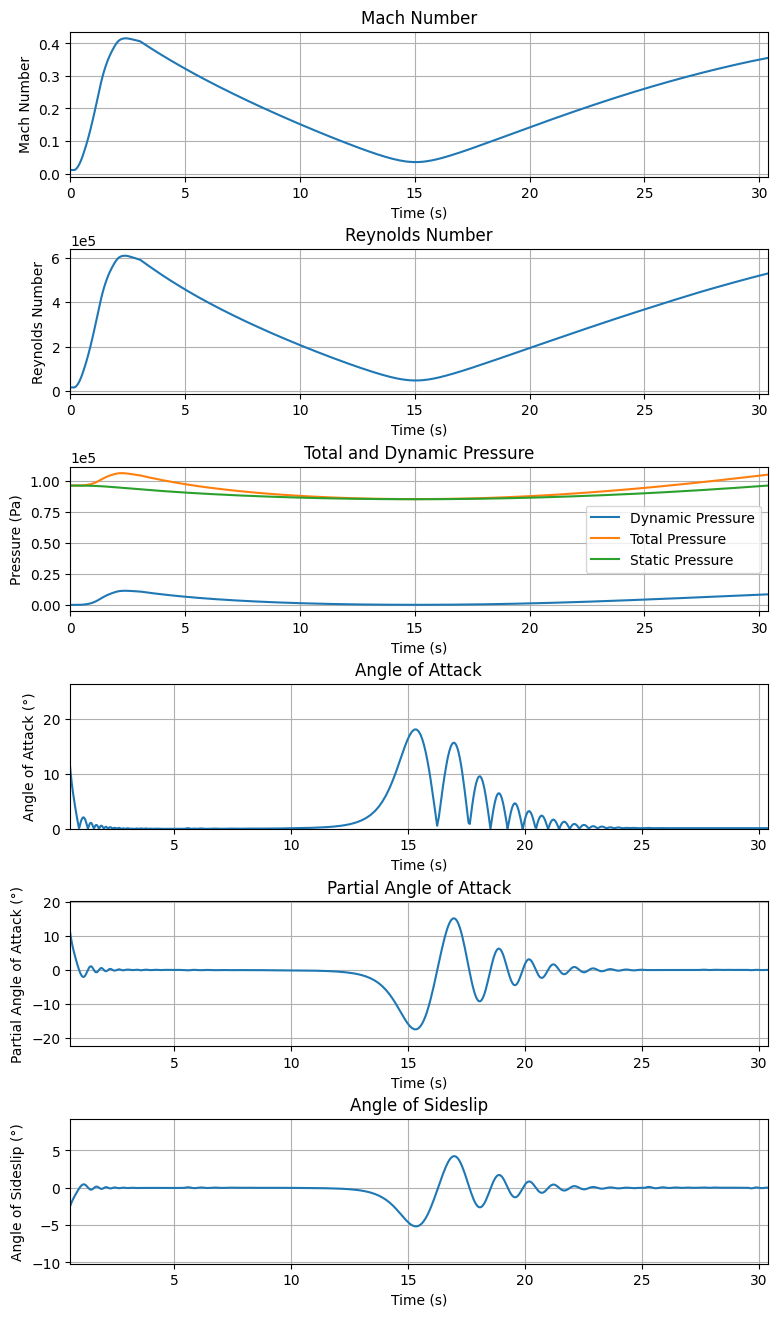



Trajectory Stability and Control Plots



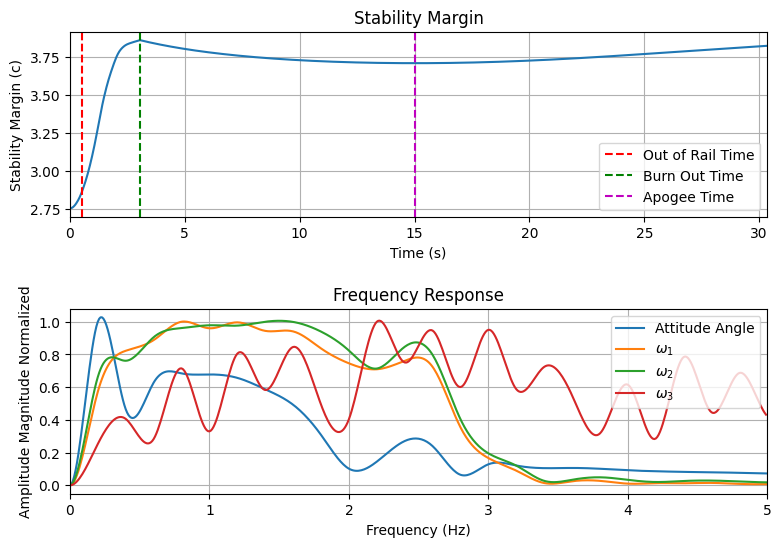



Rocket and Parachute Pressure Plots



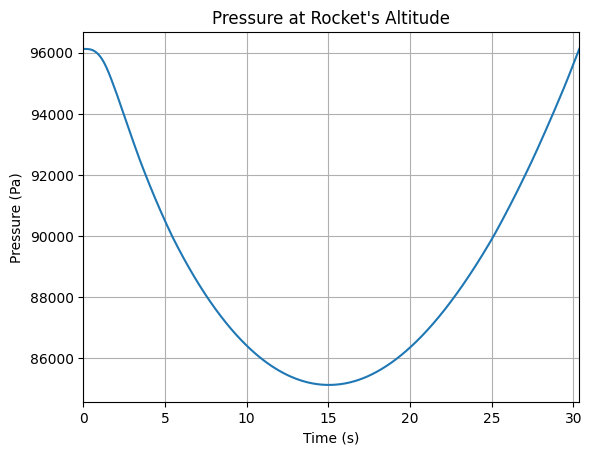

Rocket has no parachutes. No parachute plots available.



Pipeline executado sem falhas. Dados consolidados.


In [37]:
env = set_env(days_to_launch = LAUNCH_DAYS_FROM_NOW, hour = LAUNCH_HOUR, atm_type = "Windy", atm_file = "ECMWF", max_altitude = 1800, datum = "SIRGAS2000", verbose = False)
deimos_ii = set_rocket(motor_type = "BATES", flight_case = "ballistic", lag_paraquedas = 3.5, custom_altitude = 300, drag_source = "RASAero", verbose = False, return_structure = False)
flight_custom = set_flight(motor_type = "BATES", flight_case = "ballistic", lag_paraquedas = 3.5, custom_altitude = 300, drag_source = "RASAero", verbose = True)


      INICIANDO SIMULAÇÃO ESTOCÁSTICA (MONTE CARLO)      
Objetos determinísticos (nominais) montados com sucesso.

--- Condições Estocásticas ---

Reporting the attributes of the `StochasticEnvironment` object:

Constant Attributes:
	datum                    SIRGAS2000
	elevation                493
	gravity                  Function from R1 to R1 : (height (m)) → (gravity (m/s²))
	latitude                 -21.9430589
	longitude                -48.9524268
	timezone                 America/Sao_Paulo

Stochastic Attributes:
	wind_velocity_x_factor   1.00000 ± 0.15000 (normal)
	wind_velocity_y_factor   1.00000 ± 0.15000 (normal)
Reporting the attributes of the `StochasticSolidMotor` object:

Constant Attributes:
	burn_out_time                    3.048
	burn_start_time                  0
	center_of_dry_mass_position      0.190255
	coordinate_system_orientation    nozzle_to_combustion_chamber
	dry_I_11                         0.001
	dry_I_12                         0
	dry_I_13             

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\rocketpy\simulation\monte_carlo.py:139: UserWarning: This class is still under testing and some attributes may be changed in next versions
  warnings.warn(


The following input file was imported: deimos_ii_mc.inputs.txt
A total of 10 simulation results were loaded from: deimos_ii_mc.outputs.txt
The following error file was imported: deimos_ii_mc.errors.txt
Rodando 100 simulações (paralelo = True)
Starting Monte Carlo analysis
Running Monte Carlo simulation with 4 workers.
Results saved to deimos_ii_mc.outputs.txt

--- Resumo Estatístico do Monte Carlo ---

Monte Carlo Simulation by RocketPy
Data Source:  deimos_ii_mc
Number of simulations:  100
Results: 

                Parameter            Mean          Median       Std. Dev.    95% PI Lower    95% PI Upper
--------------------------------------------------------------------------------------------------------------
          impact_velocity          -6.021          -6.016           0.225          -6.460          -5.628
                  t_final         161.624         161.801           8.782         142.966         179.856
     out_of_rail_velocity          21.536          21.531       

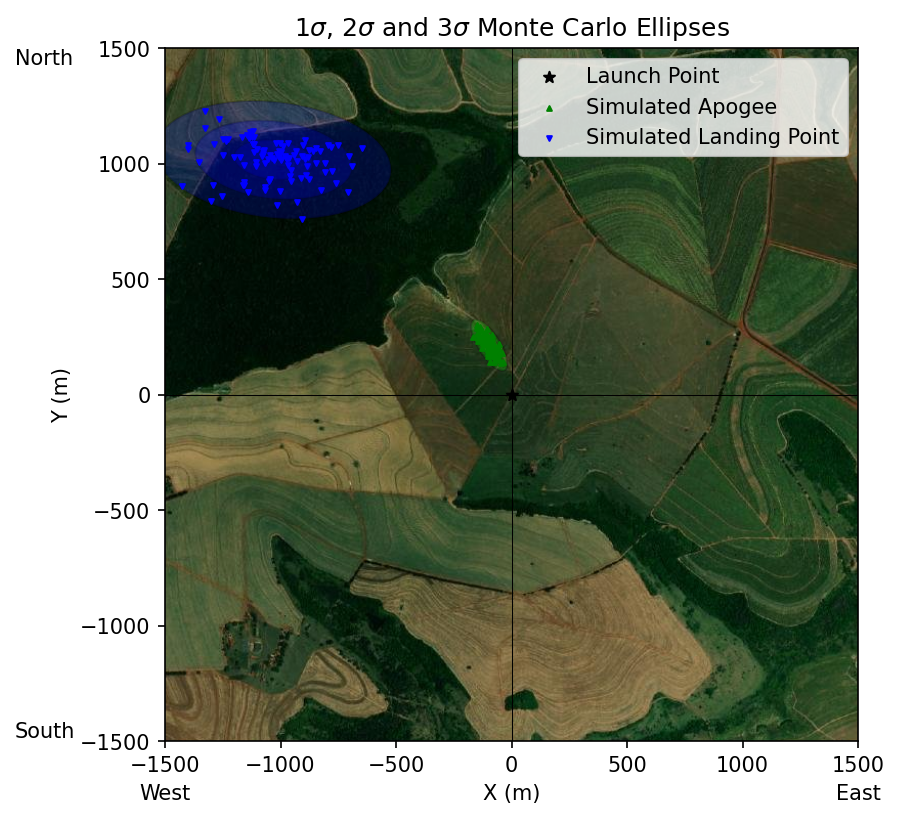

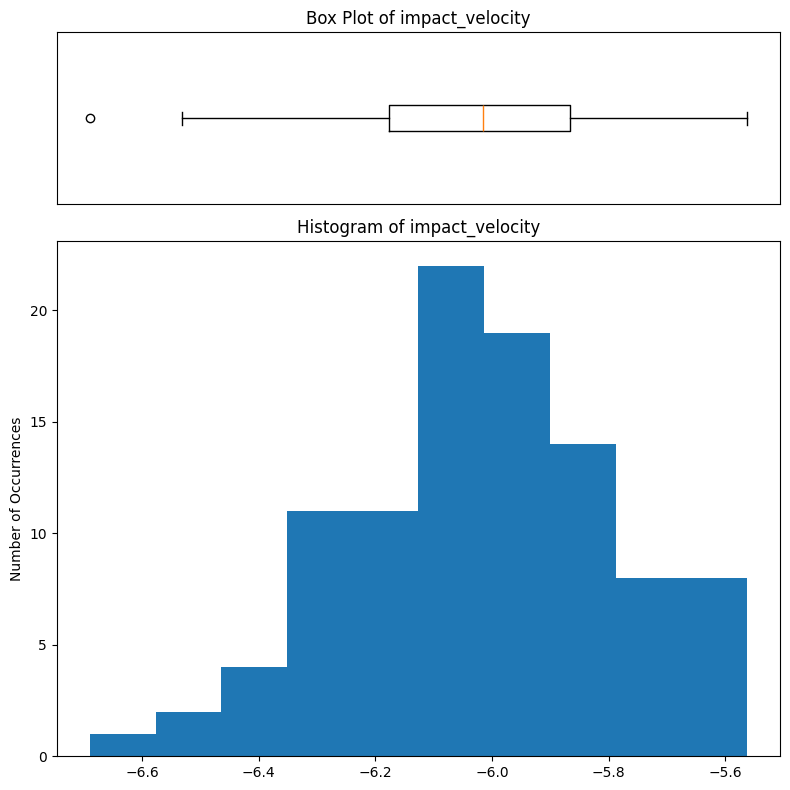

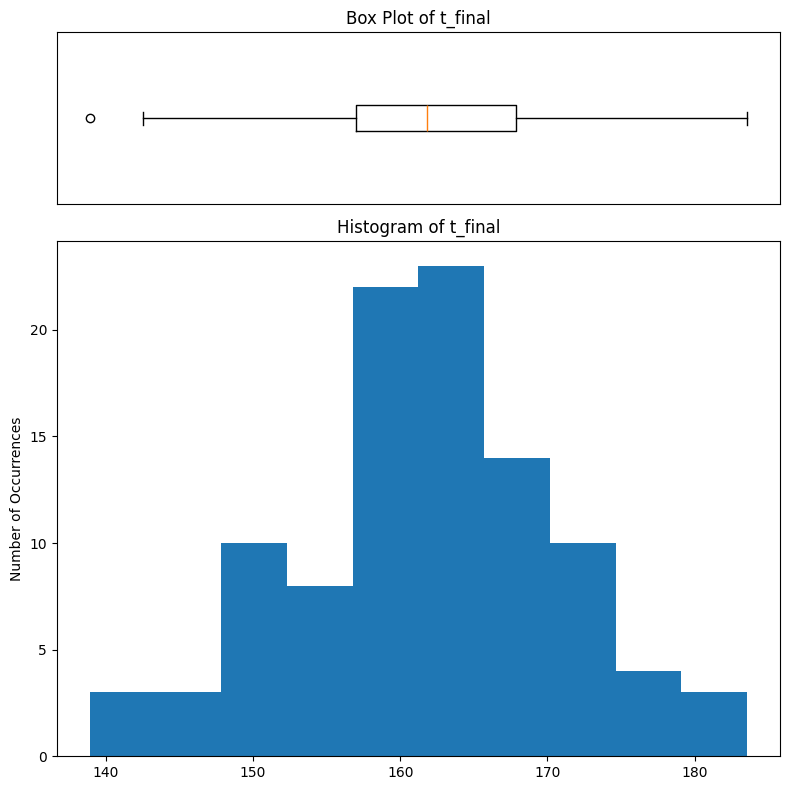

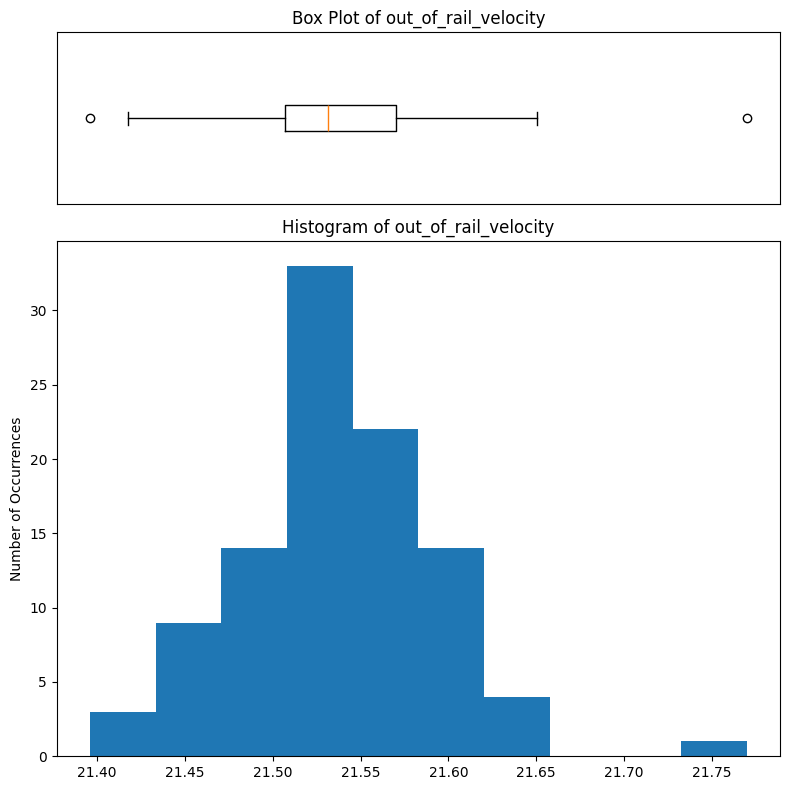

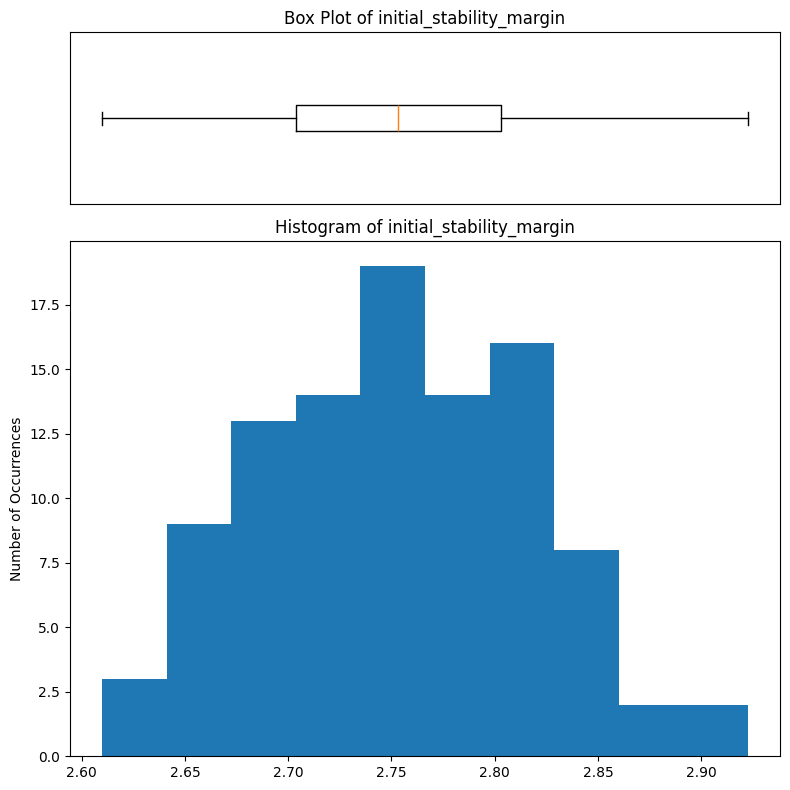

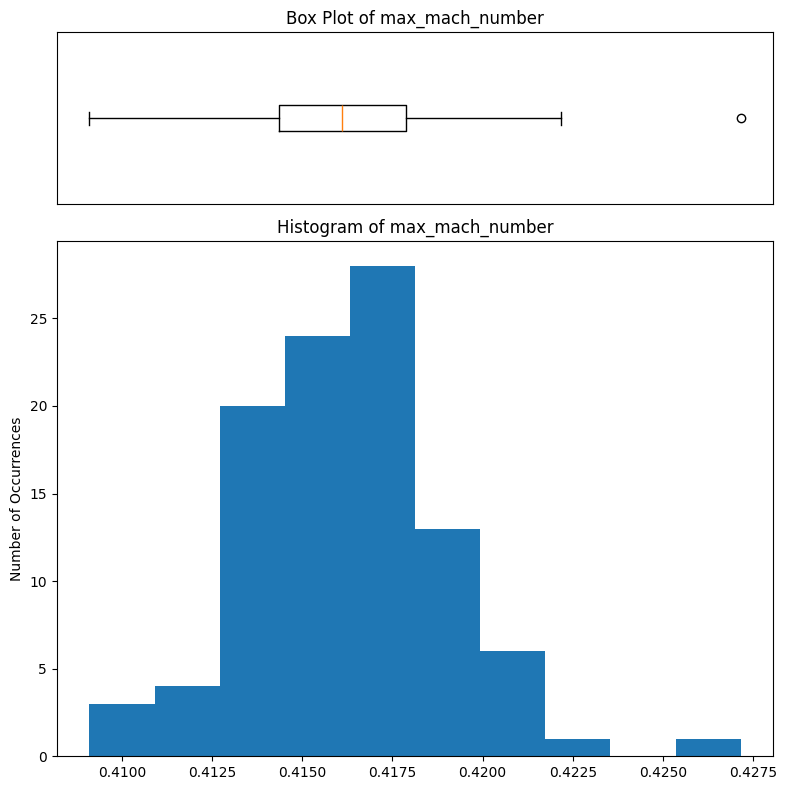

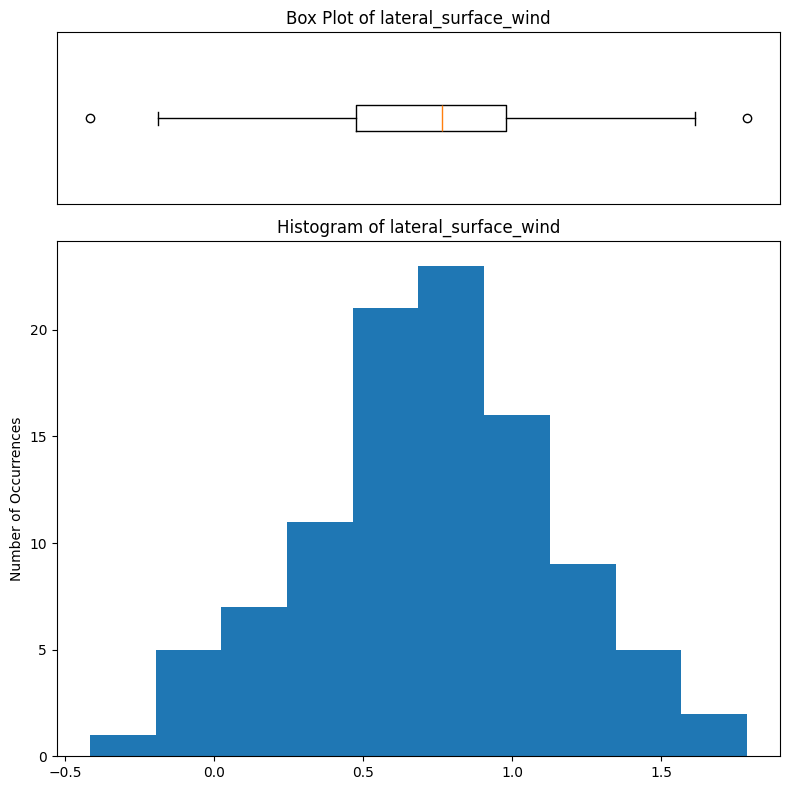

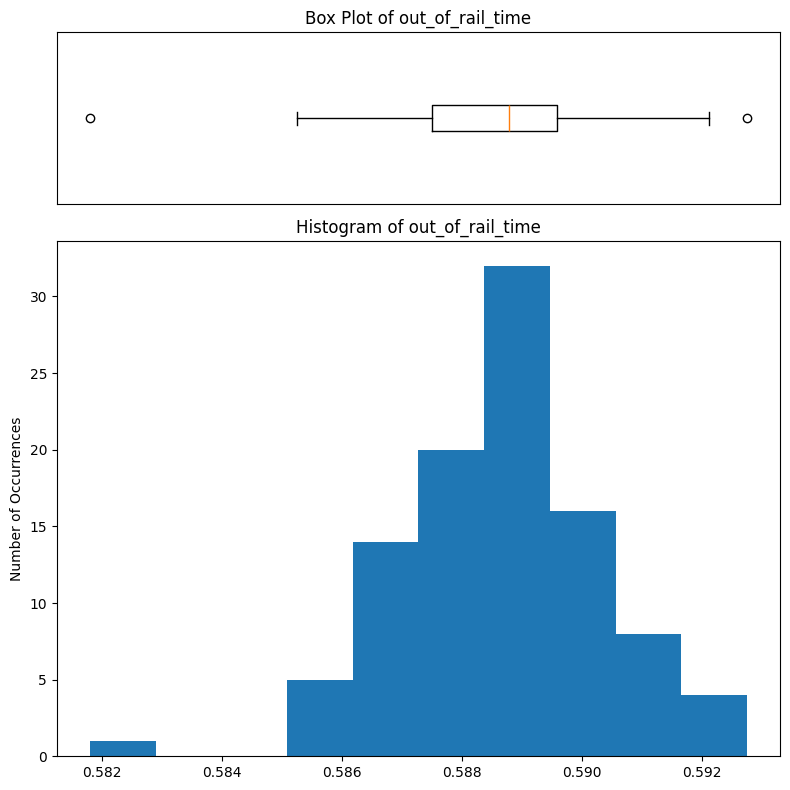

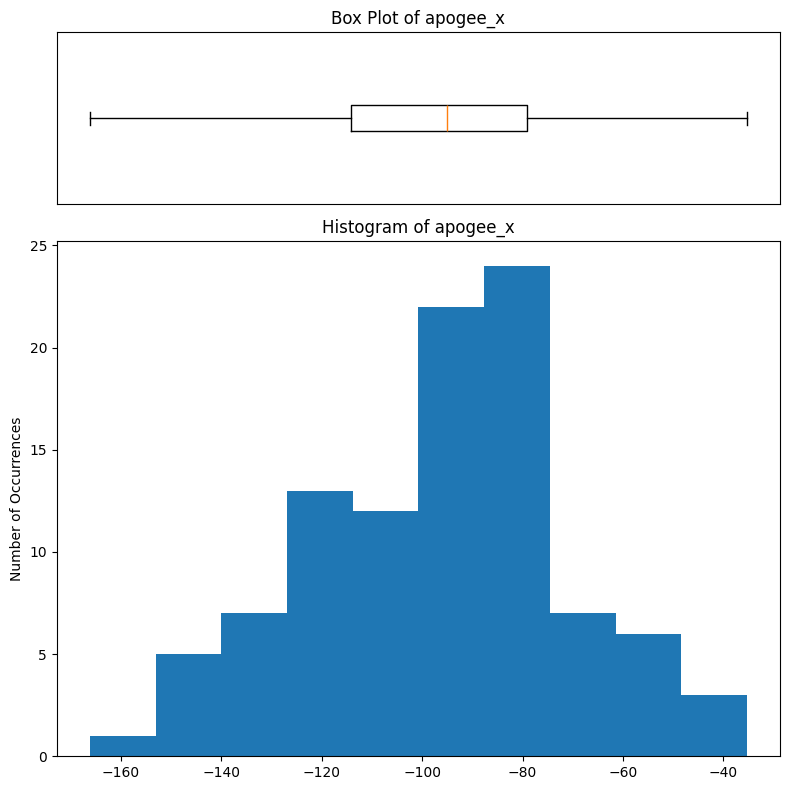

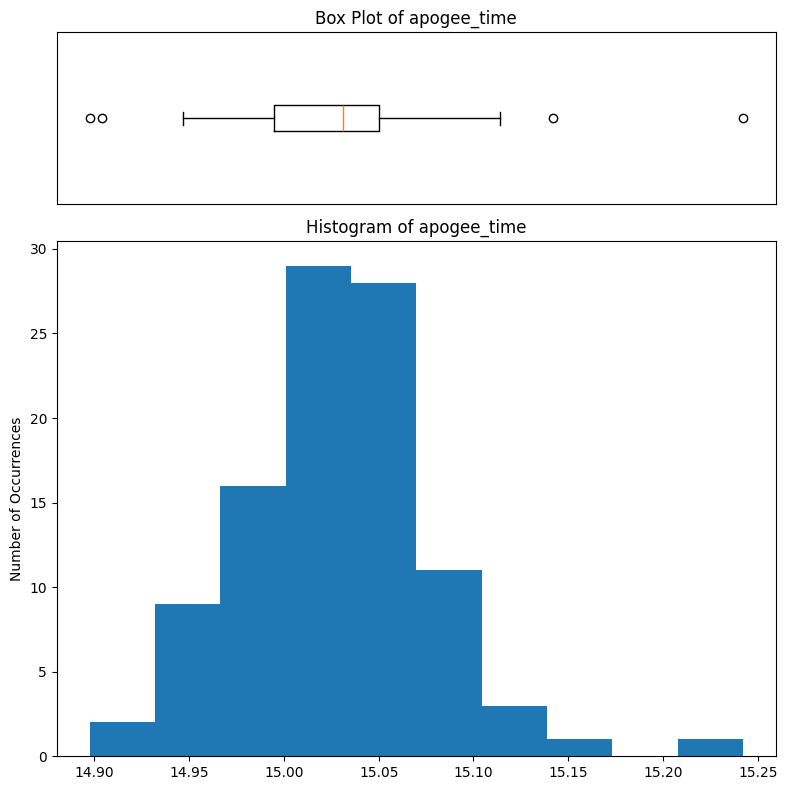

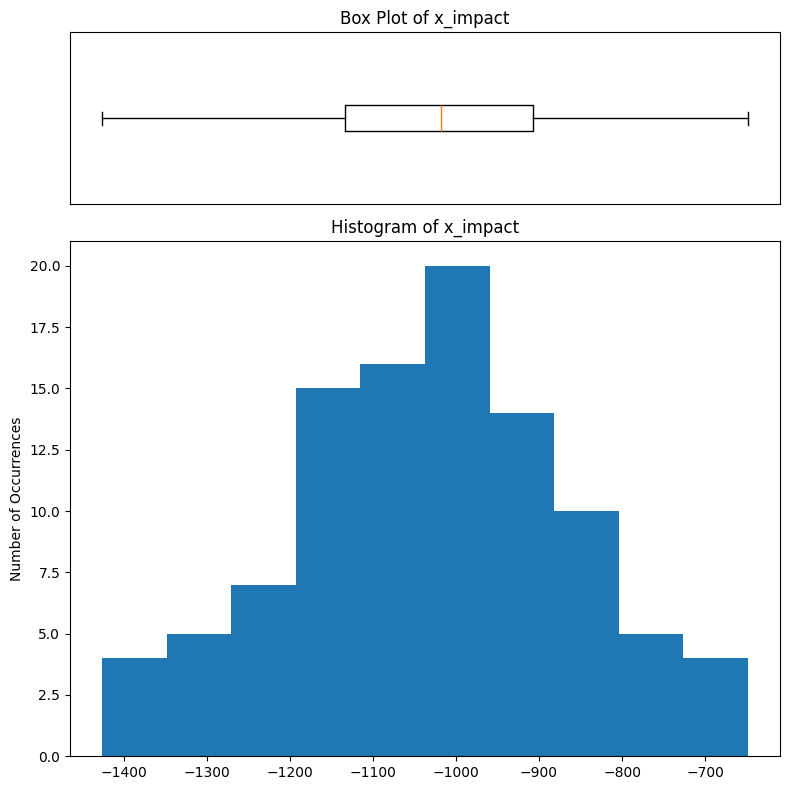

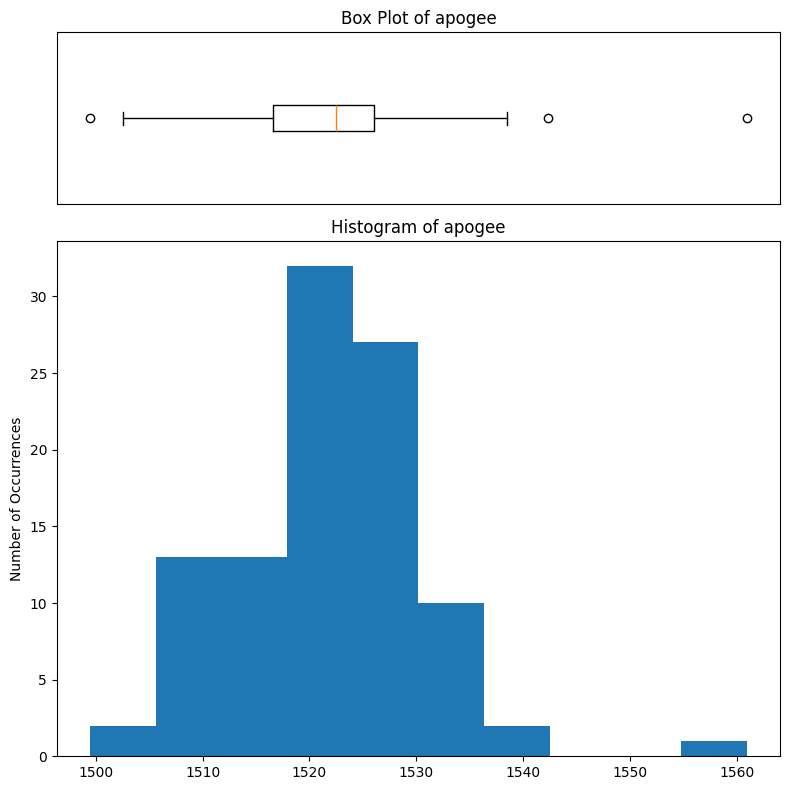

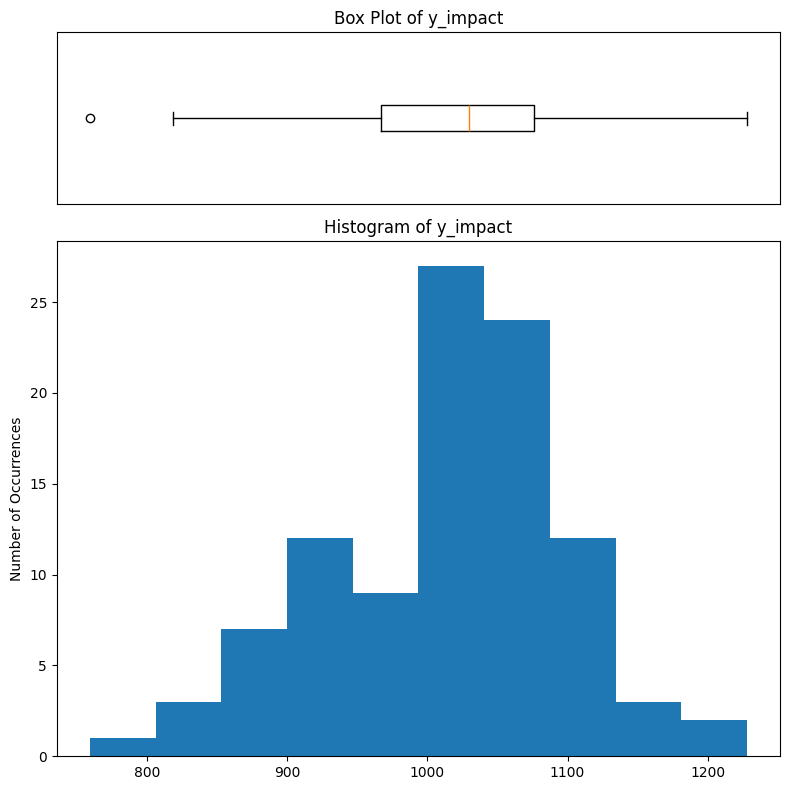

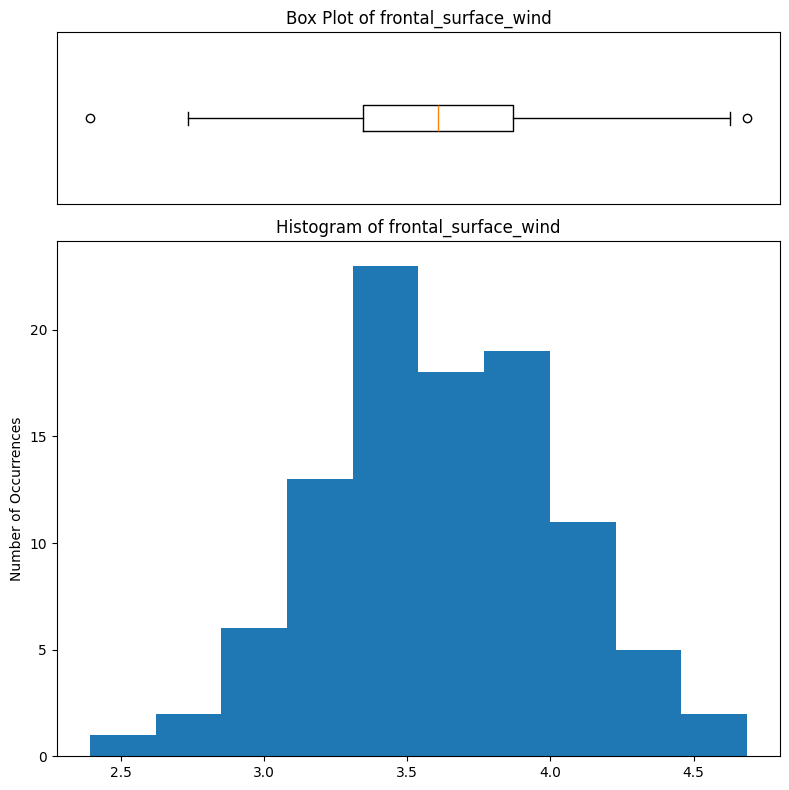

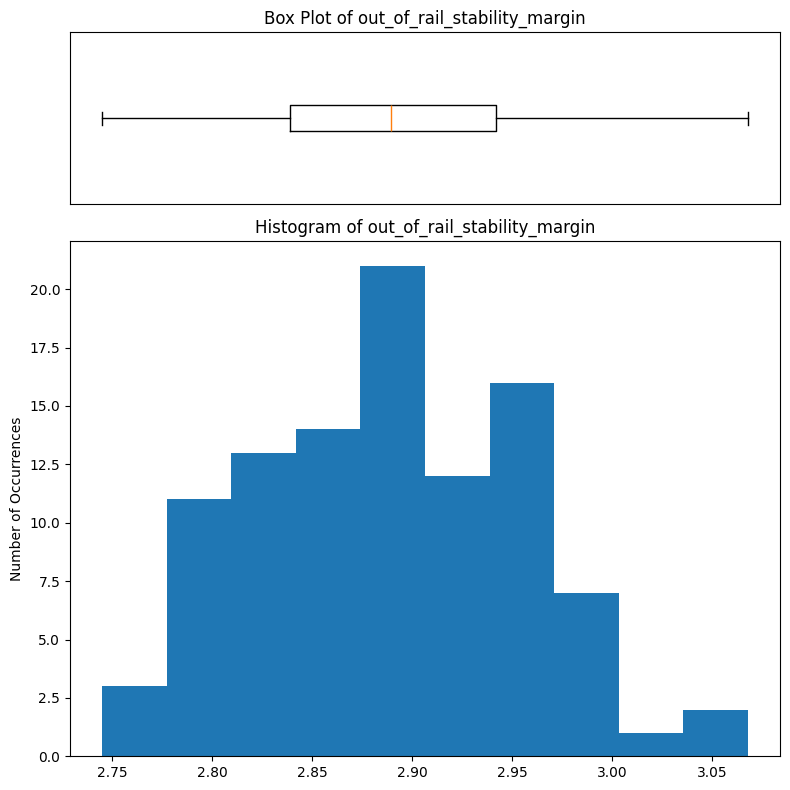

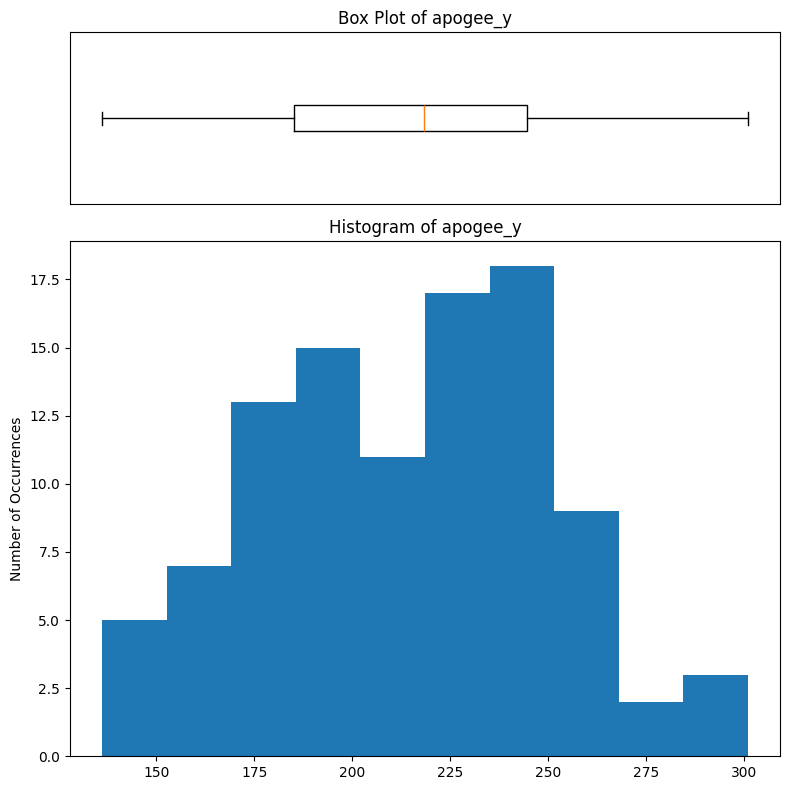

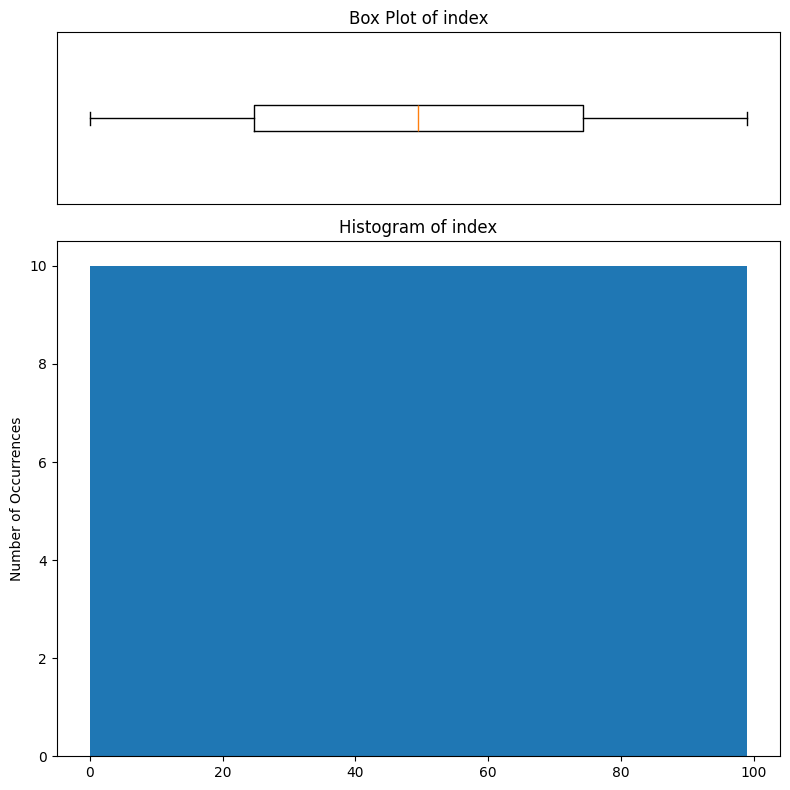


Análise estocástica concluída. Resultados salvos em: deimos_ii_mc


In [38]:
mc_deimos = set_stochastic_flight(motor_type = "BATES", flight_case = "nominal", number_of_simulations = 100, filename = "deimos_ii_mc", parallel = True, n_workers = 4, verbose = True, return_structure = True)


      INICIANDO SIMULAÇÃO ESTOCÁSTICA (MONTE CARLO)      
Objetos determinísticos (nominais) montados com sucesso.
Caso BALLÍSTICO: nunhum paraquedas estocástico adicionado.

--- Condições Estocásticas ---

Reporting the attributes of the `StochasticEnvironment` object:

Constant Attributes:
	datum                    SIRGAS2000
	elevation                493
	gravity                  Function from R1 to R1 : (height (m)) → (gravity (m/s²))
	latitude                 -21.9430589
	longitude                -48.9524268
	timezone                 America/Sao_Paulo

Stochastic Attributes:
	wind_velocity_x_factor   1.00000 ± 0.15000 (normal)
	wind_velocity_y_factor   1.00000 ± 0.15000 (normal)
Reporting the attributes of the `StochasticSolidMotor` object:

Constant Attributes:
	burn_out_time                    3.048
	burn_start_time                  0
	center_of_dry_mass_position      0.190255
	coordinate_system_orientation    nozzle_to_combustion_chamber
	dry_I_11                         0.001

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\rocketpy\simulation\monte_carlo.py:139: UserWarning: This class is still under testing and some attributes may be changed in next versions
  warnings.warn(


The following input file was imported: deimos_ii_mcb.inputs.txt
A total of 10 simulation results were loaded from: deimos_ii_mcb.outputs.txt
The following error file was imported: deimos_ii_mcb.errors.txt
Rodando 100 simulações (paralelo = True)
Starting Monte Carlo analysis
Running Monte Carlo simulation with 4 workers.
Results saved to deimos_ii_mcb.outputs.txt

--- Resumo Estatístico do Monte Carlo ---

Monte Carlo Simulation by RocketPy
Data Source:  deimos_ii_mcb
Number of simulations:  99
Results: 

                Parameter            Mean          Median       Std. Dev.    95% PI Lower    95% PI Upper
--------------------------------------------------------------------------------------------------------------
          impact_velocity        -121.241        -121.272           0.439        -122.149        -120.279
     lateral_surface_wind           1.199           1.201           0.242           0.757           1.688
     frontal_surface_wind           1.575           1.558   

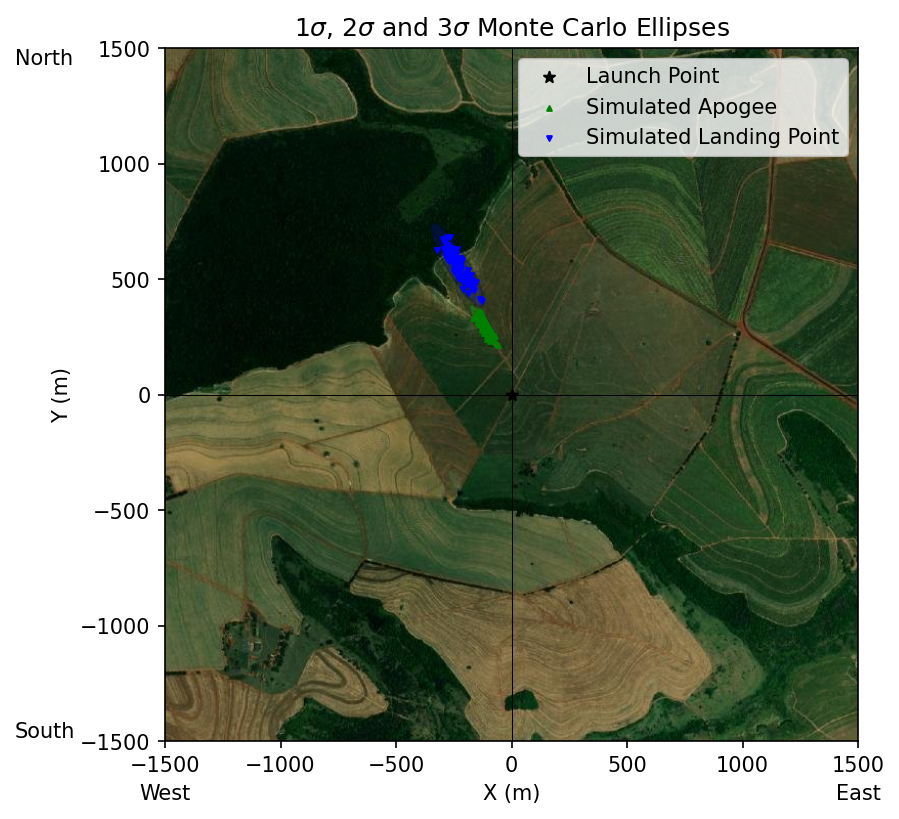

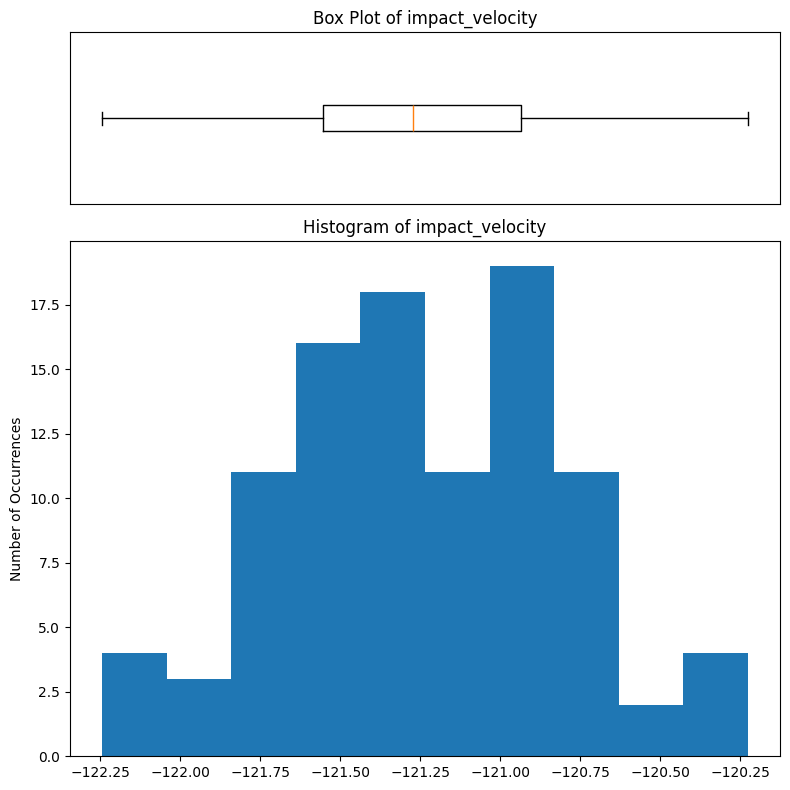

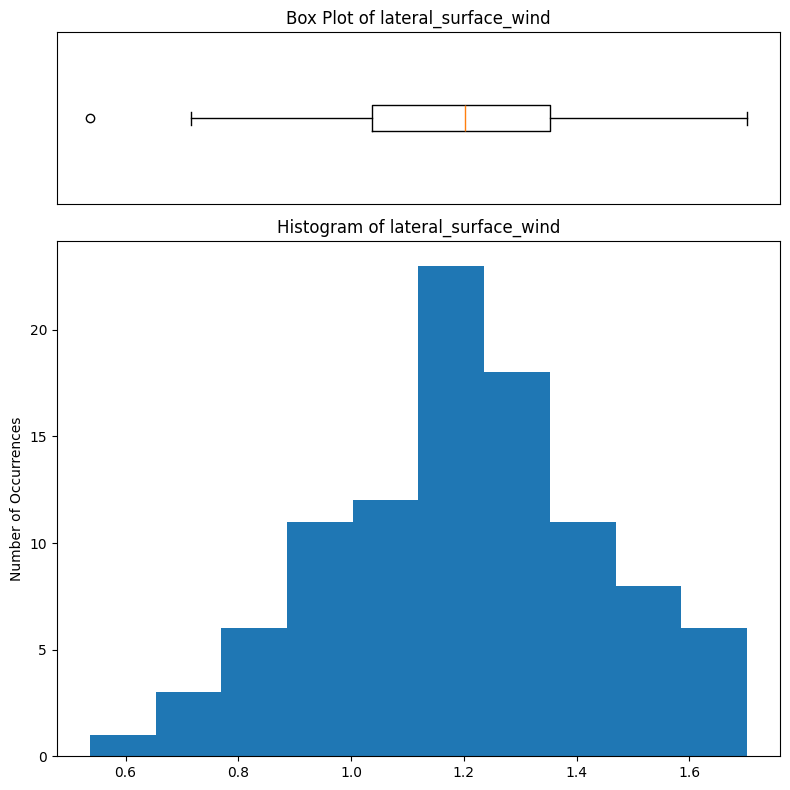

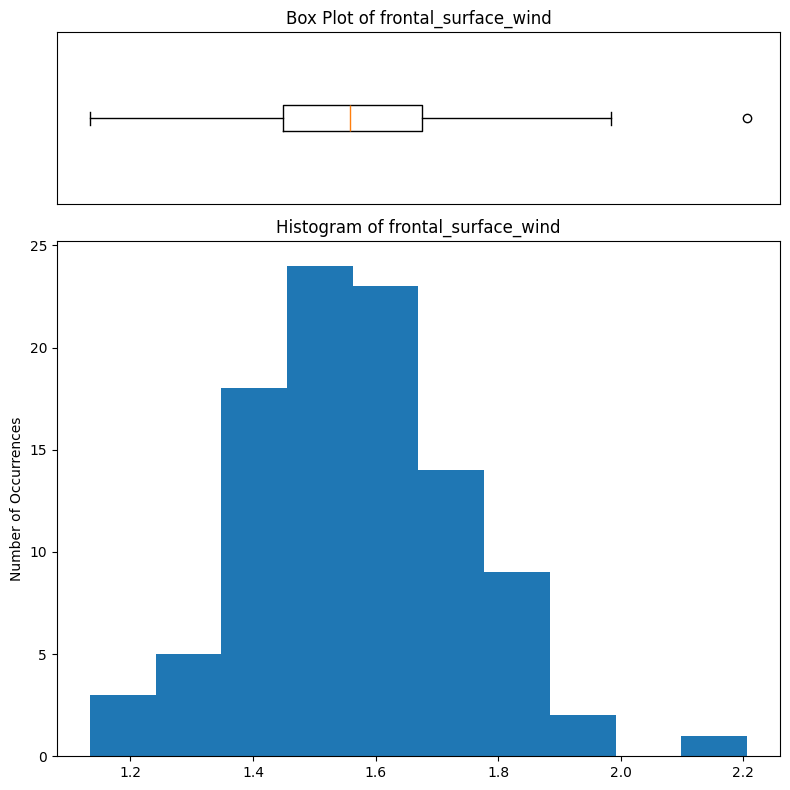

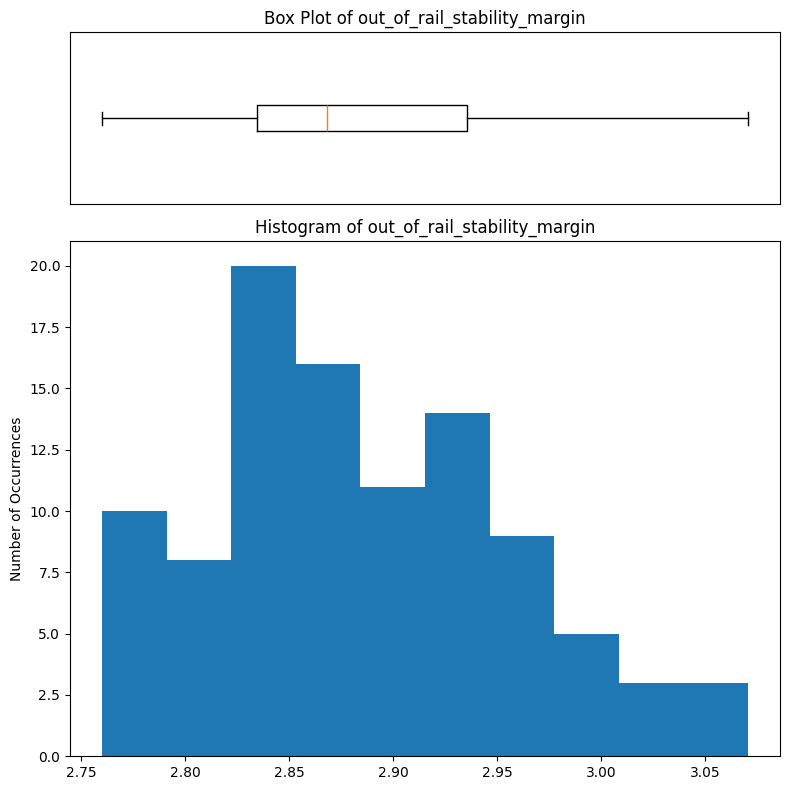

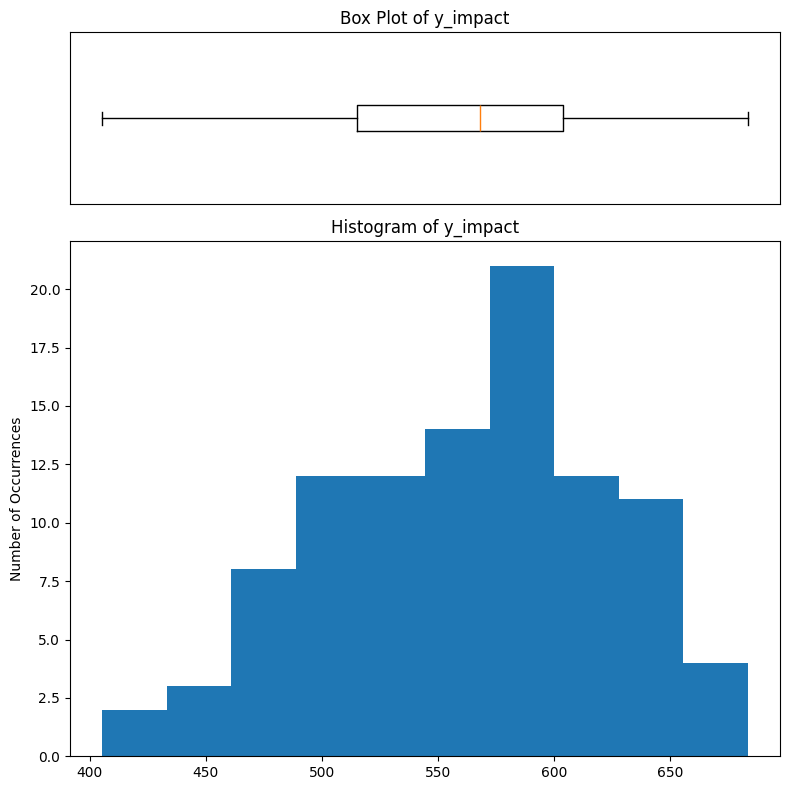

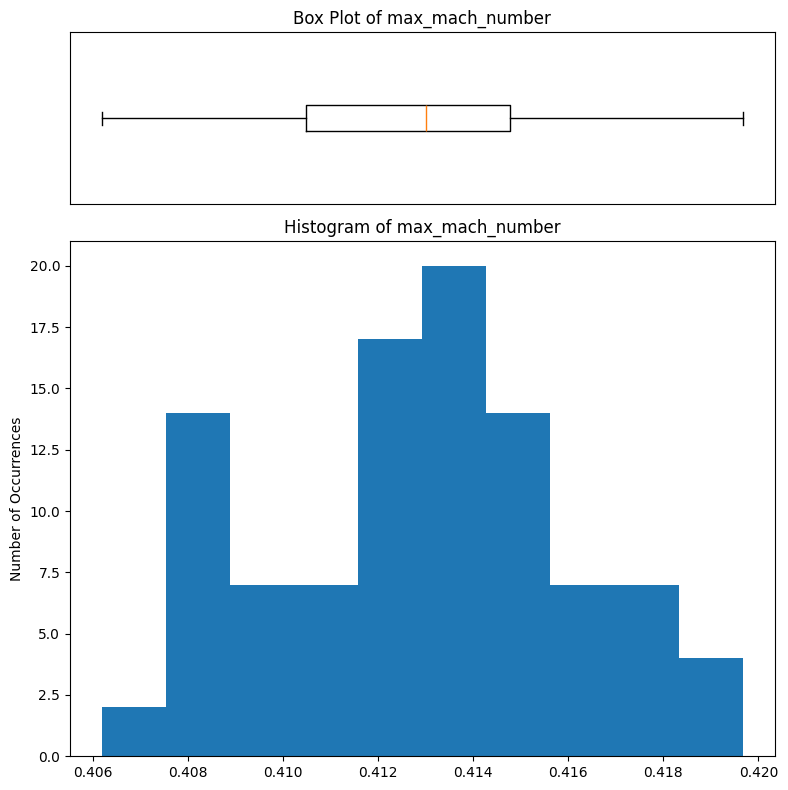

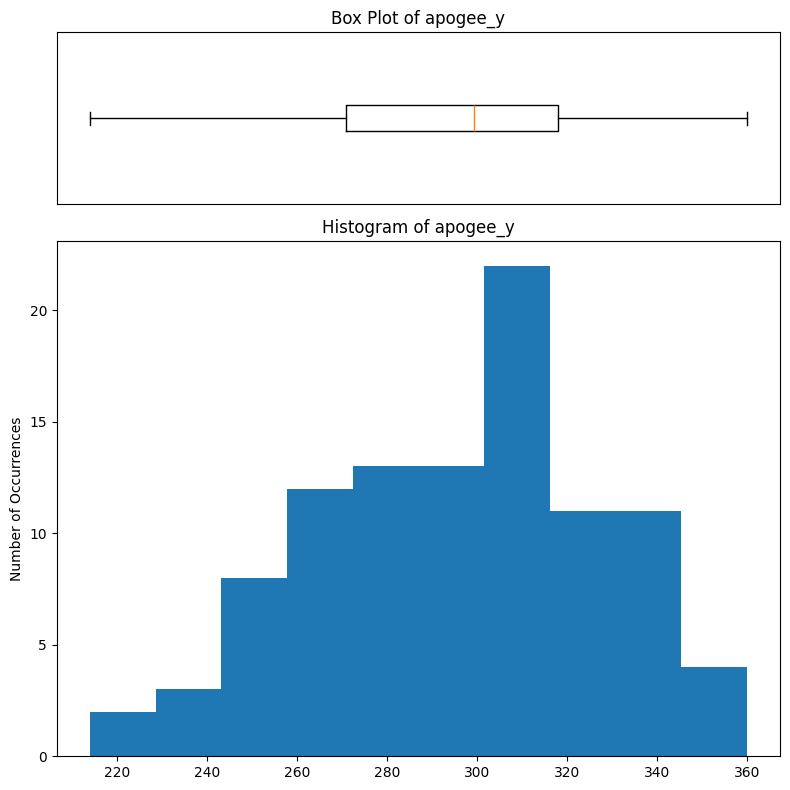

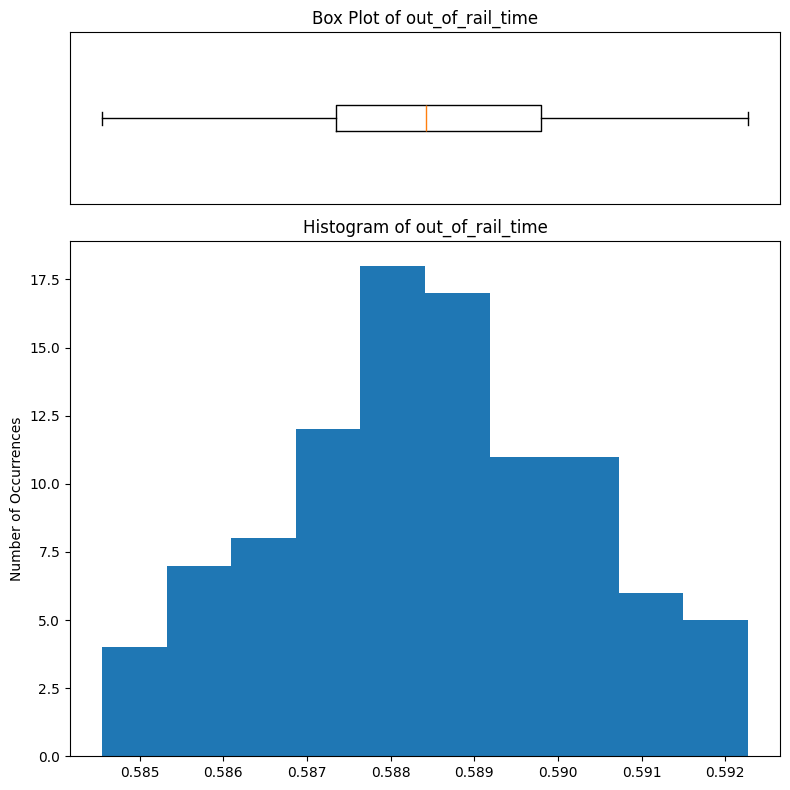

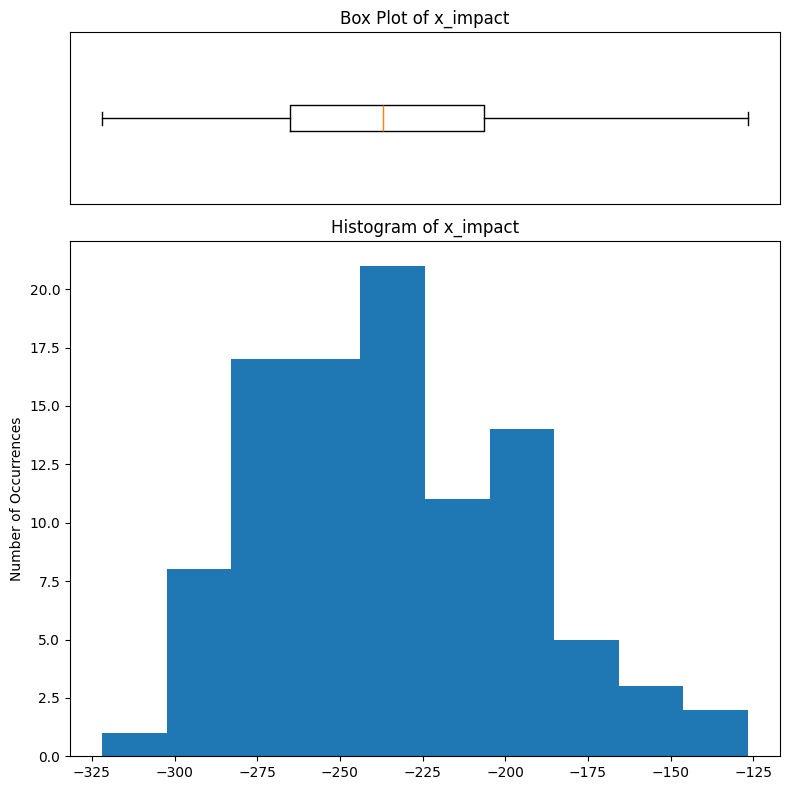

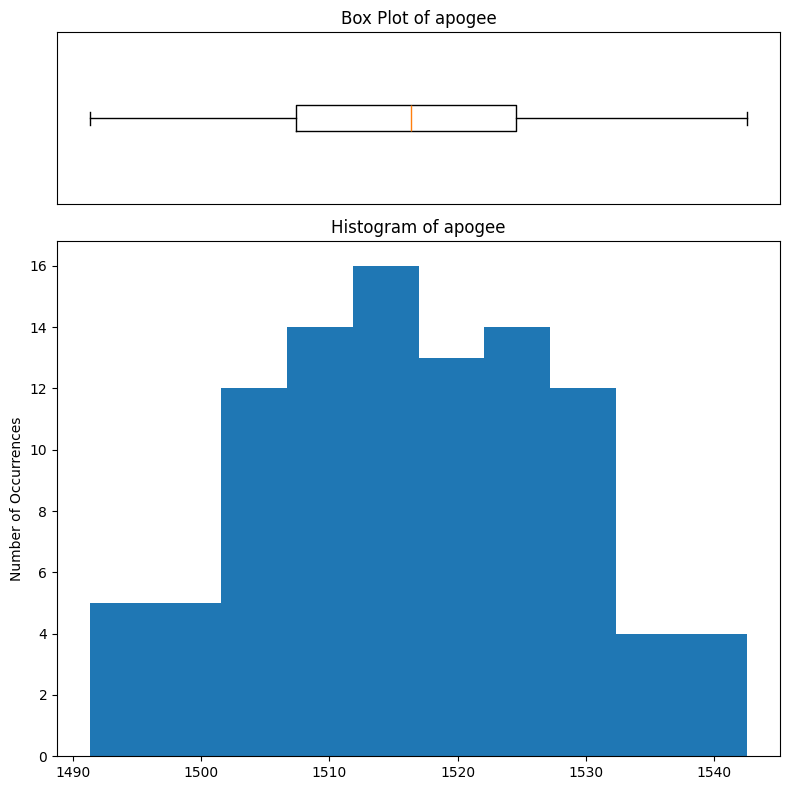

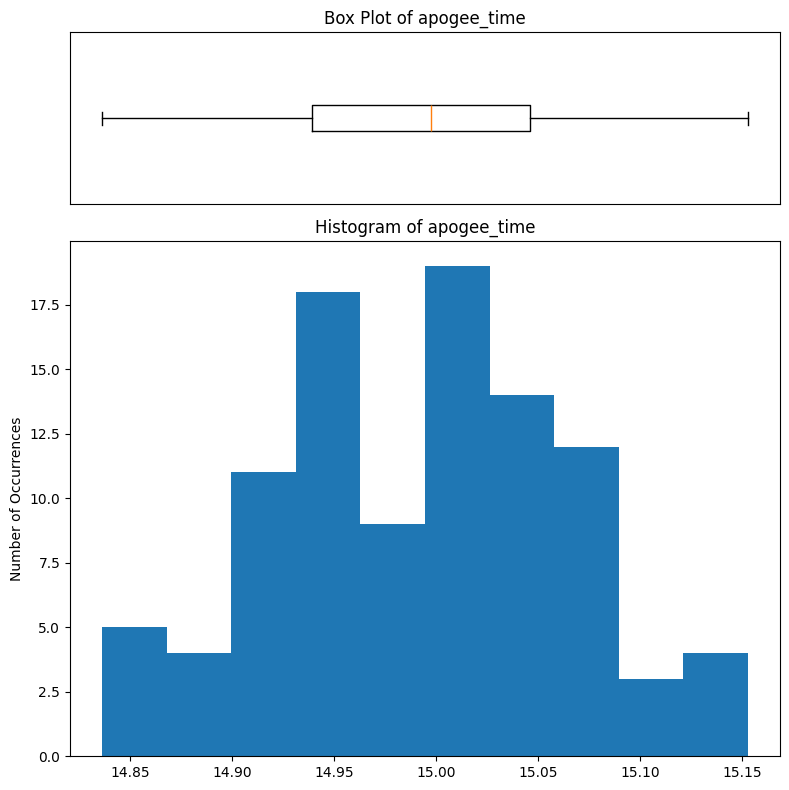

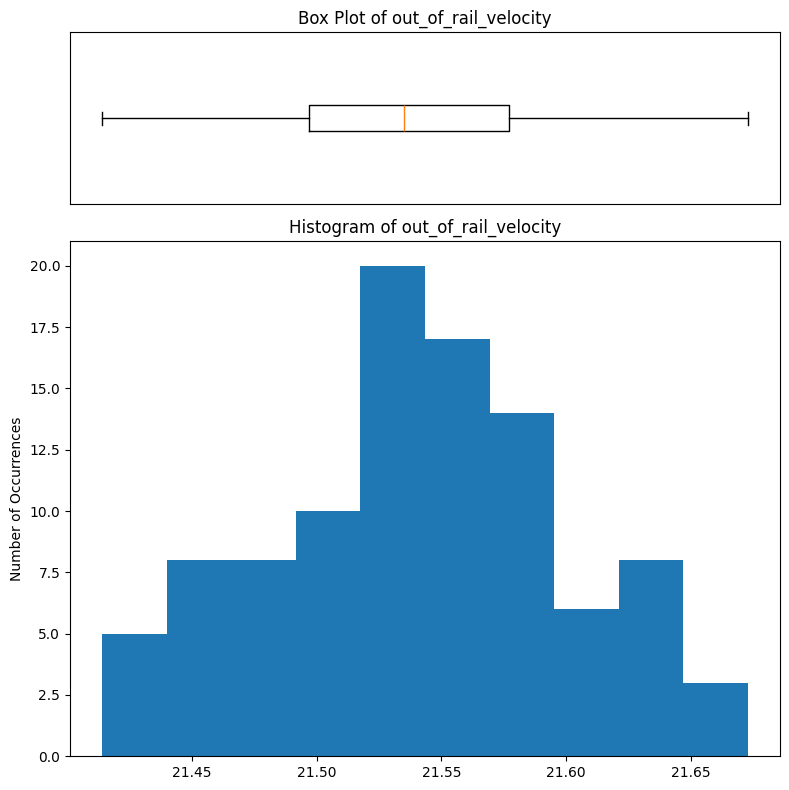

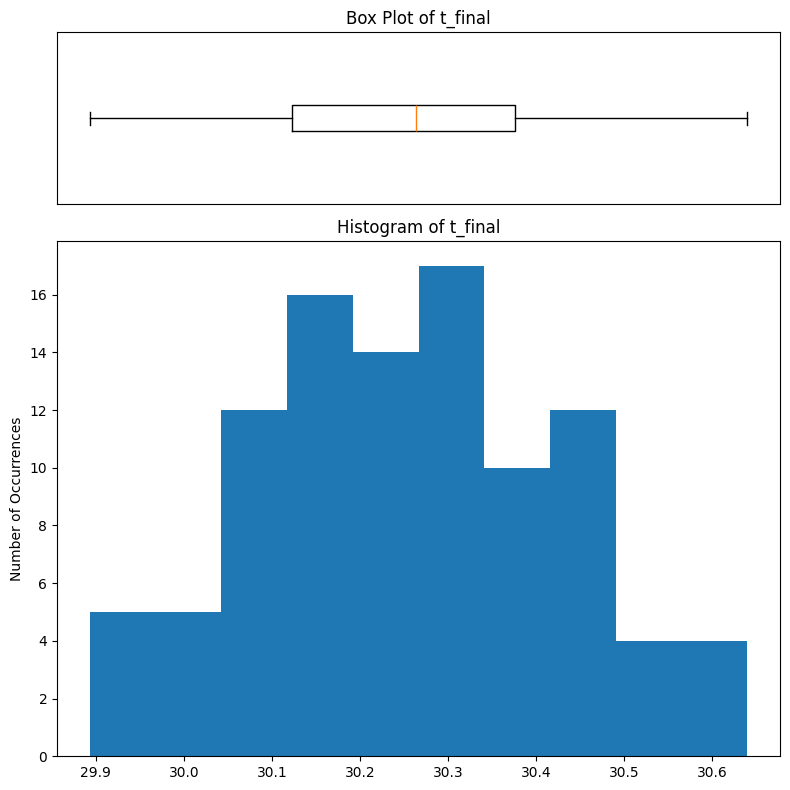

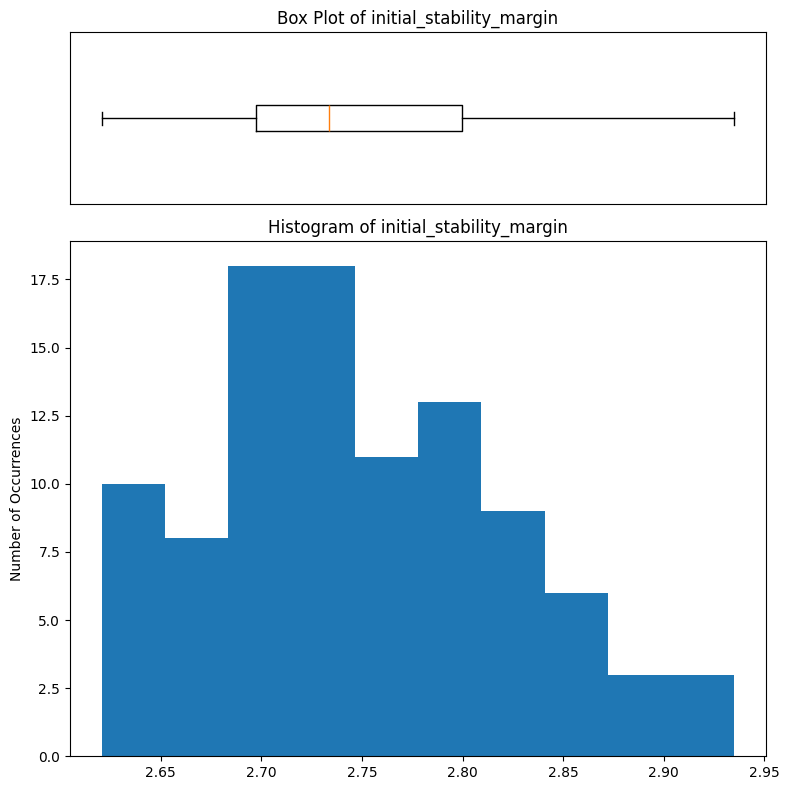

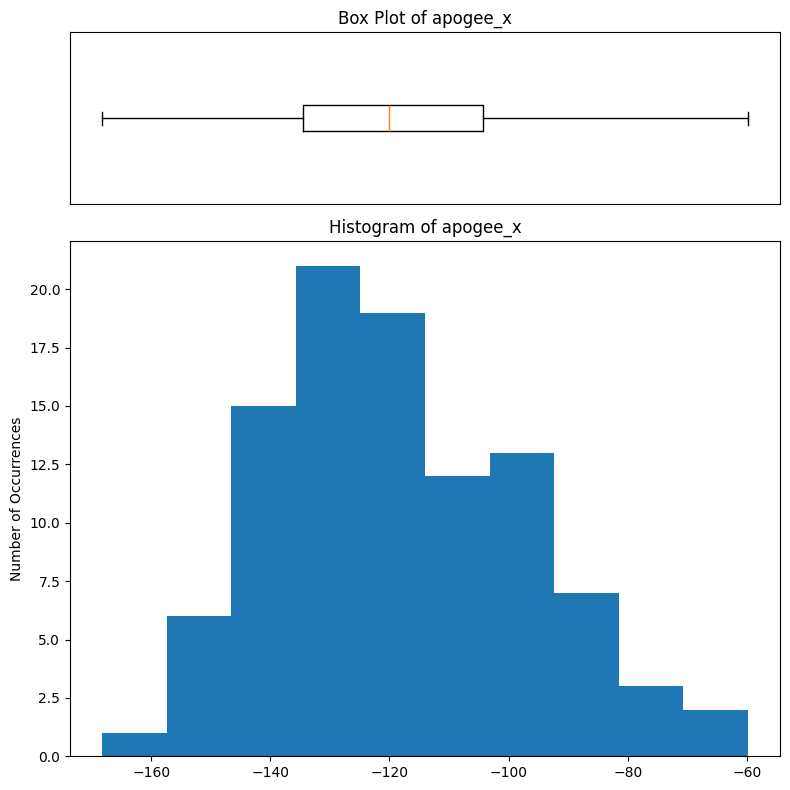

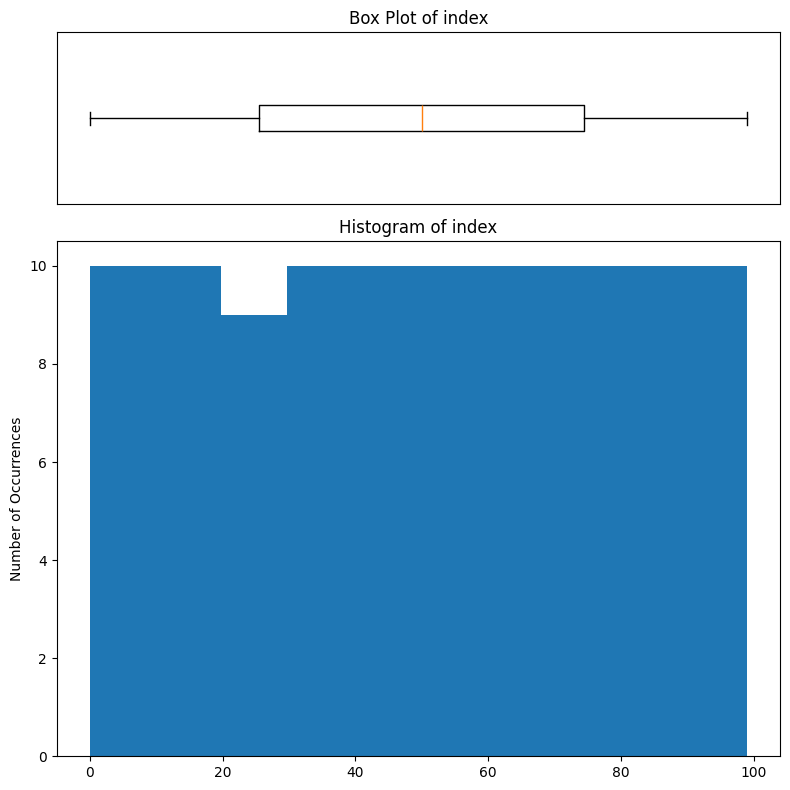


Análise estocástica concluída. Resultados salvos em: deimos_ii_mcb


In [39]:
mc_deimos = set_stochastic_flight(motor_type = "BATES", flight_case = "ballistic", lag_paraquedas = 3.5, custom_altitude = 300, drag_source = "RASAero", number_of_simulations = 100, filename = "deimos_ii_mcb", parallel = True, n_workers = 4, verbose = True, return_structure = True)